In [ ]:
# =============================================================================
# ATEPP ATTENTION ROLLOUT — 3/6/12 kihi võrdlus
# =============================================================================
# Analüüsib heliloojate klassifikaatori tähelepanumustreid.
# Võrdleb rollout'i viimase 3, 6 ja kõigi 12 kihiga.
# Visualiseerib piano roll'ina + salvestab MIDI velocity-põhiselt.
# =============================================================================
 # # 1. SEADISTUS + MUDELI LAADIMINE
!git clone https://github.com/wazenmai/MIDI-BERT.git
%cd MIDI-BERT
!pip install miditoolkit==0.1.14 mido==1.2.10 numpy transformers seaborn matplotlib scikit-learn pandas tqdm

import sys, os, pickle, tempfile, glob, copy
import torch
import torch.nn as nn
import numpy as np
import miditoolkit
from transformers import BertConfig
from google.colab import drive

if os.path.basename(os.getcwd()) != "MIDI-BERT":
    %cd MIDI-BERT
sys.path.append(os.getcwd())

!mkdir -p Data/CP_data/tmp
!mkdir -p data_creation/prepare_data/dict
!python data_creation/prepare_data/dict/make_dict.py

from data_creation.prepare_data.model import CP
from MidiBERT.model import MidiBert
np.int = int

drive.mount('/content/drive')

# Sõnastik
dict_path = 'data_creation/prepare_data/dict/CP.pkl'
with open(dict_path, 'rb') as f:
    e2w, w2e = pickle.load(f)

# MidiBERT konfiguratsioon
config = BertConfig(
    max_position_embeddings=512,
    position_embedding_type='relative_key_query',
    hidden_size=768, num_attention_heads=12, num_hidden_layers=12,
    pad_token_id=0, output_attentions=True, attn_implementation="eager"
)
config._attn_implementation = "eager"
midibert_base = MidiBert(bertConfig=config, e2w=e2w, w2e=w2e)

# Klassifikaator — TÄPSELT sama arhitektuur kui treenimisel
class ComposerClassifier(nn.Module):
    def __init__(self, pretrained_midibert, num_classes):
        super().__init__()
        self.midibert = pretrained_midibert
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attn_mask, return_attentions=False):
        embs = [self.midibert.word_emb[i](input_ids[..., i])
                for i, _ in enumerate(self.midibert.classes)]
        emb_linear = self.midibert.in_linear(torch.cat([*embs], dim=-1))

        outputs = self.midibert.bert(
            inputs_embeds=emb_linear, attention_mask=attn_mask,
            output_hidden_states=True, output_attentions=True
        )

        hidden = outputs.last_hidden_state
        mask = attn_mask.unsqueeze(-1).float()
        summed = (hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        pooled_output = summed / counts

        logits = self.classifier(self.dropout(pooled_output))
        if return_attentions:
            return logits, outputs.attentions
        return logits


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_labels = ['Bach', 'Mozart', 'Chopin', 'Debussy']

model = ComposerClassifier(midibert_base, len(target_labels)).to(device)
model_path = "/content/drive/MyDrive/LÕPUTÖÖ/atepp_parandatud_final.pt"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

cp_model = CP(dict=dict_path)
PAD_BAR_IDX = e2w['Bar']['Bar <PAD>']

print(f"Mudel laetud: {model_path}")
print(f"Seade: {device}")
print(f"Klassid: {target_labels}")
print("VALMIS!")

Cloning into 'MIDI-BERT'...
remote: Enumerating objects: 1258, done.
remote: Counting objects: 100% (392/392), done.
remote: Compressing objects: 100% (254/254), done.
remote: Total 1258 (delta 171), reused 344 (delta 134), pack-reused 866 (from 1)
Receiving objects: 100% (1258/1258), 125.78 MiB | 7.14 MiB/s, done.
Resolving deltas: 100% (619/619), done.
Updating files: 100% (164/164), done.
/content/MIDI-BERT
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 5.6 MB/s eta 0:00:00
  Created wheel for miditoolkit: filename=miditoolkit-0.1.14-py3-none-any.whl size=19508 sha256=9f296c7239e8543f34fe5eea80a1bad39f7f53eb670d4fb816af11f99ea05f25
  Stored in directory: /root/.cache/pip/wheels/f0/6e/d3/005b67a60d4a610bc9de6a19f02d205e7ce19972725138fff4
Successfully built miditoolkit
{'Bar': {'Bar New': 0, 'Bar Continue': 1, 'Bar <PAD>': 2, 'Bar <MASK>': 3}, 'Position': {'Position 1/16': 0, 'Position 2/16': 1, 'Position 3/16': 2, 'Position 4/16': 3,

In [ ]:
# # 2. ROLLOUT FUNKTSIOONID (3/6/12 kihti)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

MAX_LEN = 512


def compute_rollout(attentions, device, n_layers=None):
    """
    Attention Rollout: kumulatiivne tähelepanu.
    n_layers: None = kõik, 3 = viimased 3, 6 = viimased 6
    """
    if n_layers is not None:
        attentions = attentions[-n_layers:]

    seq_len = attentions[0].size(-1)
    result = torch.eye(seq_len).to(device)
    for attention in attentions:
        # Keskmistame üle kõigi peade
        attn_weights = attention[0].mean(dim=0)
        # Residual-ühendus
        attn_weights = attn_weights + torch.eye(seq_len).to(device)
        # Normaliseerime
        attn_weights = attn_weights / attn_weights.sum(dim=-1, keepdim=True)
        result = torch.matmul(attn_weights, result)
    return result


def analyze_midi(midi_path, model, cp_model, device, max_len=MAX_LEN):
    """
    MIDI fail → tokenid → mudel → attention rollout (3/6/12 kihti).
    Tagastab ennustuse, tõenäosused ja tokenite info koos importance'iga.
    """
    try:
        input_ids, _ = cp_model.prepare_data([midi_path], task='melody',
                                              max_len=max_len)
    except Exception as e:
        print(f"[VIGA] Tokeniseerimine: {e}")
        return None

    if len(input_ids) == 0:
        print("[VIGA] Failis pole piisavalt noote.")
        return None

    # Kasutame esimest segmenti
    input_tensor = torch.tensor(input_ids[0], dtype=torch.long).unsqueeze(0).to(device)
    attn_mask = (input_tensor[:, :, 0] != PAD_BAR_IDX).float().to(device)

    with torch.no_grad():
        logits, attentions = model(input_tensor, attn_mask, return_attentions=True)
        probs = torch.nn.functional.softmax(logits, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()

    # Rollout 3 varianti
    rollouts = {}
    for n_layers in [3, 6, None]:
        label = f"{n_layers or 12} kihti"
        rollout_matrix = compute_rollout(attentions, device, n_layers)
        token_importance = rollout_matrix.mean(dim=0).cpu().numpy()
        ti_min, ti_max = token_importance.min(), token_importance.max()
        if ti_max > ti_min:
            norm_imp = (token_importance - ti_min) / (ti_max - ti_min)
        else:
            norm_imp = np.zeros_like(token_importance)
        rollouts[label] = norm_imp

    # Dekodeeri tokenid
    segment = input_ids[0]
    midi_info = miditoolkit.MidiFile(midi_path)
    if midi_info.time_signature_changes:
        ts = midi_info.time_signature_changes[0]
        beats_per_bar = ts.numerator * (4.0 / ts.denominator)
    else:
        beats_per_bar = 4.0

    token_notes = []
    current_bar = -1

    for i, token in enumerate(segment):
        b_idx = int(token[0])
        p_idx = int(token[1])
        pt_idx = int(token[2])
        d_idx = int(token[3])

        bar_str = w2e['Bar'].get(b_idx, '')
        pos_str = w2e['Position'].get(p_idx, '')
        pitch_str = w2e['Pitch'].get(pt_idx, '')
        dur_str = w2e['Duration'].get(d_idx, '')

        if '<PAD>' in bar_str or '<MASK>' in bar_str:
            continue
        if '<PAD>' in pitch_str or '<MASK>' in pitch_str:
            continue

        if bar_str == 'Bar New':
            current_bar += 1

        try:
            pos_val = int(pos_str.split(' ')[1].split('/')[0]) - 1
            offset = pos_val * (beats_per_bar / 16.0)
        except:
            offset = 0.0

        try:
            pitch = int(pitch_str.split(' ')[1])
        except:
            continue

        try:
            dur_val = int(dur_str.split(' ')[1])
        except:
            dur_val = 1

        abs_start = (current_bar * beats_per_bar) + offset

        imp_dict = {label: float(imp[i]) for label, imp in rollouts.items()}

        token_notes.append({
            'pitch': pitch,
            'abs_start': abs_start,
            'duration': dur_val,
            'token_idx': i,
            'bar': current_bar,
            'position': pos_str,
            'importance': imp_dict
        })

    # Prindi kokkuvõte
    print(f"Ennustus: {target_labels[predicted_class]} "
          f"({probs[0][predicted_class].item()*100:.1f}%)")
    for i, label in enumerate(target_labels):
        bar = '█' * int(probs[0][i].item() * 30)
        print(f"  {label:>8s}: {probs[0][i].item()*100:5.1f}% {bar}")
    print(f"Tokeneid (mitte-PAD): {len(token_notes)}")

    return {
        'probs': probs,
        'predicted_class': predicted_class,
        'token_notes': token_notes,
        'beats_per_bar': beats_per_bar,
        'rollouts': rollouts,
        'midi_path': midi_path
    }


print("Analüüsifunktsioonid valmis!")

Analüüsifunktsioonid valmis!


In [ ]:
# # 3. VISUALISEERIMISE FUNKTSIOONID

# %%
def plot_piano_roll_attention(result, true_label, layer_key='3 kihti',
                               title_extra='', figsize=(18, 6)):
    """
    Piano roll visualiseerimine attention rollout värvimisega.
    """
    token_notes = result['token_notes']
    if not token_notes:
        print("Pole tokeneid visualiseerimiseks.")
        return

    pred_label = target_labels[result['predicted_class']]
    prob = result['probs'][0][result['predicted_class']].item() * 100
    fname = os.path.basename(result['midi_path'])

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.cm.OrRd

    importances = [tn['importance'][layer_key] for tn in token_notes]
    pitches = [tn['pitch'] for tn in token_notes]
    starts = [tn['abs_start'] for tn in token_notes]

    # Piano roll — iga noot on ristkülik
    for tn in token_notes:
        imp = tn['importance'][layer_key]
        color = cmap(0.2 + imp * 0.8)
        width = max(tn['duration'] * 0.15, 0.3)
        rect = plt.Rectangle(
            (tn['abs_start'], tn['pitch'] - 0.4),
            width, 0.8,
            facecolor=color, edgecolor='black', linewidth=0.3, alpha=0.9
        )
        ax.add_patch(rect)

    ax.set_xlim(min(starts) - 0.5, max(starts) + 2)
    ax.set_ylim(min(pitches) - 2, max(pitches) + 2)
    ax.set_xlabel('Aeg (löögid)', fontsize=12)
    ax.set_ylabel('MIDI helikõrgus', fontsize=12)

    correct = "✓" if pred_label == true_label else "✗"
    ax.set_title(f'{fname} — Tegelik: {true_label}, Ennustus: {pred_label} '
                 f'({prob:.0f}%) {correct}  [{layer_key}] {title_extra}',
                 fontsize=13, fontweight='bold')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label('Attention Rollout', fontsize=11)

    plt.tight_layout()
    return fig


def plot_layer_comparison(result, true_label, figsize=(18, 14)):
    """
    Kolme kihi variandi kõrvuti võrdlus.
    """
    token_notes = result['token_notes']
    if not token_notes:
        return

    fname = os.path.basename(result['midi_path'])
    pred_label = target_labels[result['predicted_class']]
    prob = result['probs'][0][result['predicted_class']].item() * 100
    correct = "✓" if pred_label == true_label else "✗"

    layer_keys = ['3 kihti', '6 kihti', '12 kihti']
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, sharey=True)

    cmap = plt.cm.OrRd
    pitches = [tn['pitch'] for tn in token_notes]
    starts = [tn['abs_start'] for tn in token_notes]

    for ax, layer_key in zip(axes, layer_keys):
        for tn in token_notes:
            imp = tn['importance'][layer_key]
            color = cmap(0.2 + imp * 0.8)
            width = max(tn['duration'] * 0.05, 0.15)
            rect = plt.Rectangle(
                (tn['abs_start'], tn['pitch'] - 0.4),
                width, 0.8,
                facecolor=color, edgecolor='black', linewidth=0.3, alpha=0.9
            )
            ax.add_patch(rect)

        ax.set_xlim(min(starts) - 0.5, max(starts) + 2)
        ax.set_ylim(min(pitches) - 2, max(pitches) + 2)
        ax.set_ylabel('MIDI helikõrgus', fontsize=10)
        ax.set_title(f'{layer_key}', fontsize=12, fontweight='bold')

    axes[-1].set_xlabel('Aeg (löögid)', fontsize=11)

    fig.suptitle(f'{fname} — Tegelik: {true_label}, Ennustus: {pred_label} '
                 f'({prob:.0f}%) {correct}',
                 fontsize=14, fontweight='bold')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])

    # Colorbar eraldi teljel paremal, ei kattu andmetega
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.10, 0.02, 0.78])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Attention Rollout', fontsize=11)

    return fig


def plot_importance_distribution(result, true_label, figsize=(14, 5)):
    """
    Importance jaotuste histogramm kolme kihi variandi jaoks.
    """
    token_notes = result['token_notes']
    fname = os.path.basename(result['midi_path'])
    pred_label = target_labels[result['predicted_class']]

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    layer_keys = ['3 kihti', '6 kihti', '12 kihti']
    colors = ['#e74c3c', '#f39c12', '#3498db']

    for ax, layer_key, color in zip(axes, layer_keys, colors):
        importances = [tn['importance'][layer_key] for tn in token_notes]
        ax.hist(importances, bins=30, color=color, alpha=0.7, edgecolor='black')
        ax.set_title(f'{layer_key}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance')
        ax.axvline(np.mean(importances), color='black', linestyle='--',
                   label=f'keskm={np.mean(importances):.3f}')
        ax.legend(fontsize=9)

    axes[0].set_ylabel('Tokeneid')
    correct = "✓" if pred_label == true_label else "✗"
    fig.suptitle(f'{fname} — {true_label}→{pred_label} {correct} — '
                 f'importance jaotus', fontsize=13)
    plt.tight_layout()
    return fig


def export_attention_midi(result, output_path, layer_key='3 kihti'):
    """
    Salvestab MIDI, kus velocity peegeldab attention rollout importance't.
    """
    midi = miditoolkit.MidiFile(result['midi_path'])

    # Ehitame token importance kaardi: (pitch, approx_tick) → importance
    tpb = midi.ticks_per_beat
    token_notes = result['token_notes']

    for inst in midi.instruments:
        for note in inst.notes:
            # Leiame lähima tokeni
            best_imp = 0.0
            best_dist = float('inf')
            note_beat = note.start / tpb

            for tn in token_notes:
                pitch_diff = abs(note.pitch - tn['pitch'])
                time_diff = abs(note_beat - tn['abs_start'])
                dist = pitch_diff * 2 + time_diff

                if dist < best_dist and pitch_diff <= 1:
                    best_dist = dist
                    best_imp = tn['importance'][layer_key]

            note.velocity = int(5 + best_imp * 122)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    midi.dump(output_path)
    print(f"  MIDI salvestatud: {output_path}")


def export_attention_musicxml(result, output_path, true_label,
                               layer_key='3 kihti',
                               threshold=0.3, cmap_name='OrRd'):
    """
    Loeb MIDI music21-ga, värvib noodid attention importance järgi,
    ekspordib MusicXML-ina (avamiseks MuseScore'is).
    """
    import music21 as m21
    import matplotlib
    import matplotlib.colors as mcolors
    from scipy.spatial.distance import cdist

    cmap = matplotlib.colormaps[cmap_name]
    token_notes = result['token_notes']
    pred_label = target_labels[result['predicted_class']]
    prob = result['probs'][0][result['predicted_class']].item() * 100
    fname = os.path.basename(result['midi_path'])

    # Loe MIDI music21-ga
    score = m21.converter.parse(result['midi_path'])

    # Kogu originaalnoodid
    original_notes = []
    for n in score.recurse().notes:
        if n.isChord:
            for p in n.pitches:
                original_notes.append({
                    'obj': n,
                    'pitch': p.midi,
                    'offset': float(n.offset + (n.activeSite.offset
                                    if n.activeSite and hasattr(n.activeSite, 'offset')
                                    else 0)),
                    'matched': False
                })
        else:
            original_notes.append({
                'obj': n,
                'pitch': n.pitch.midi,
                'offset': float(n.offset + (n.activeSite.offset
                                if n.activeSite and hasattr(n.activeSite, 'offset')
                                else 0)),
                'matched': False
            })

    if not original_notes or not token_notes:
        print(f"  [HOIATUS] Originaalnoote: {len(original_notes)}, tokeneid: {len(token_notes)}")
        score.write('musicxml', output_path, makeNotation=False)
        return score

    # Joondamine: tokenid → originaalnoodid
    max_time_orig = max(n['offset'] for n in original_notes) or 1.0
    max_time_token = max(tn['abs_start'] for tn in token_notes) or 1.0

    orig_coords = np.array([
        [n['pitch'], n['offset'] / max_time_orig * 100]
        for n in original_notes
    ])
    token_coords = np.array([
        [tn['pitch'], tn['abs_start'] / max_time_token * 100]
        for tn in token_notes
    ])

    distances = cdist(token_coords, orig_coords)

    token_to_orig = {}
    used_orig = set()
    sorted_tokens = sorted(range(len(token_notes)),
                           key=lambda i: -token_notes[i]['importance'][layer_key])

    for t_idx in sorted_tokens:
        candidates = []
        for o_idx in range(len(original_notes)):
            if o_idx in used_orig:
                continue
            pitch_diff = abs(token_notes[t_idx]['pitch'] - original_notes[o_idx]['pitch'])
            time_dist = distances[t_idx][o_idx]
            if pitch_diff <= 1:
                candidates.append((time_dist, o_idx))
        if candidates:
            candidates.sort()
            best_orig = candidates[0][1]
            token_to_orig[t_idx] = best_orig
            used_orig.add(best_orig)

    orig_importance = {}
    for t_idx, o_idx in token_to_orig.items():
        orig_importance[o_idx] = token_notes[t_idx]['importance'][layer_key]

    print(f"  Joondatud: {len(token_to_orig)}/{len(token_notes)} tokenit "
          f"→ {len(used_orig)}/{len(original_notes)} originaalnooti")

    # Värvimine
    note_obj_importance = {}
    for o_idx, note_info in enumerate(original_notes):
        if o_idx in orig_importance:
            note_obj_importance[id(note_info['obj'])] = orig_importance[o_idx]

    colored, black, grey = 0, 0, 0
    for n in score.recurse().notes:
        obj_id = id(n)
        if obj_id in note_obj_importance:
            imp = note_obj_importance[obj_id]
            if imp >= threshold:
                scaled = (imp - threshold) / (1.0 - threshold)
                rgba = cmap(0.3 + scaled * 0.7)
                color_hex = mcolors.to_hex(rgba)
                velocity = int(30 + scaled * 97)
                colored += 1
            else:
                color_hex = '#000000'
                velocity = 30
                black += 1
        else:
            color_hex = '#888888'
            velocity = 30
            grey += 1

        n.style.color = color_hex
        n.volume = m21.volume.Volume(velocity=velocity)
        if n.isChord:
            for sub in n.notes:
                sub.style.color = color_hex
                sub.volume = m21.volume.Volume(velocity=velocity)

    # Pealkiri
    if score.metadata is None:
        score.insert(0, m21.metadata.Metadata())
    correct = "✓" if pred_label == true_label else "✗"
    score.metadata.title = (f"{fname} — {true_label}→{pred_label} "
                            f"({prob:.0f}%) {correct} [{layer_key}]")

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    score.write('musicxml', output_path, makeNotation=True)
    print(f"  MusicXML salvestatud: {output_path}")
    print(f"  Värvitud: {colored} värvilist, {black} musta, {grey} halli")
    return score


print("Visualiseerimisfunktsioonid valmis!")

Visualiseerimisfunktsioonid valmis!


ATEPP MIDI faile: 11699

EKSIMUS: 02672.mid — Ennustas Chopin 95.9%
Tegelik: Bach


100%|██████████| 1/1 [00:00<00:00,  1.03it/s]


Ennustus: Chopin (91.8%)
      Bach:   7.5% ██
    Mozart:   0.2% 
    Chopin:  91.8% ███████████████████████████
   Debussy:   0.6% 
Tokeneid (mitte-PAD): 512


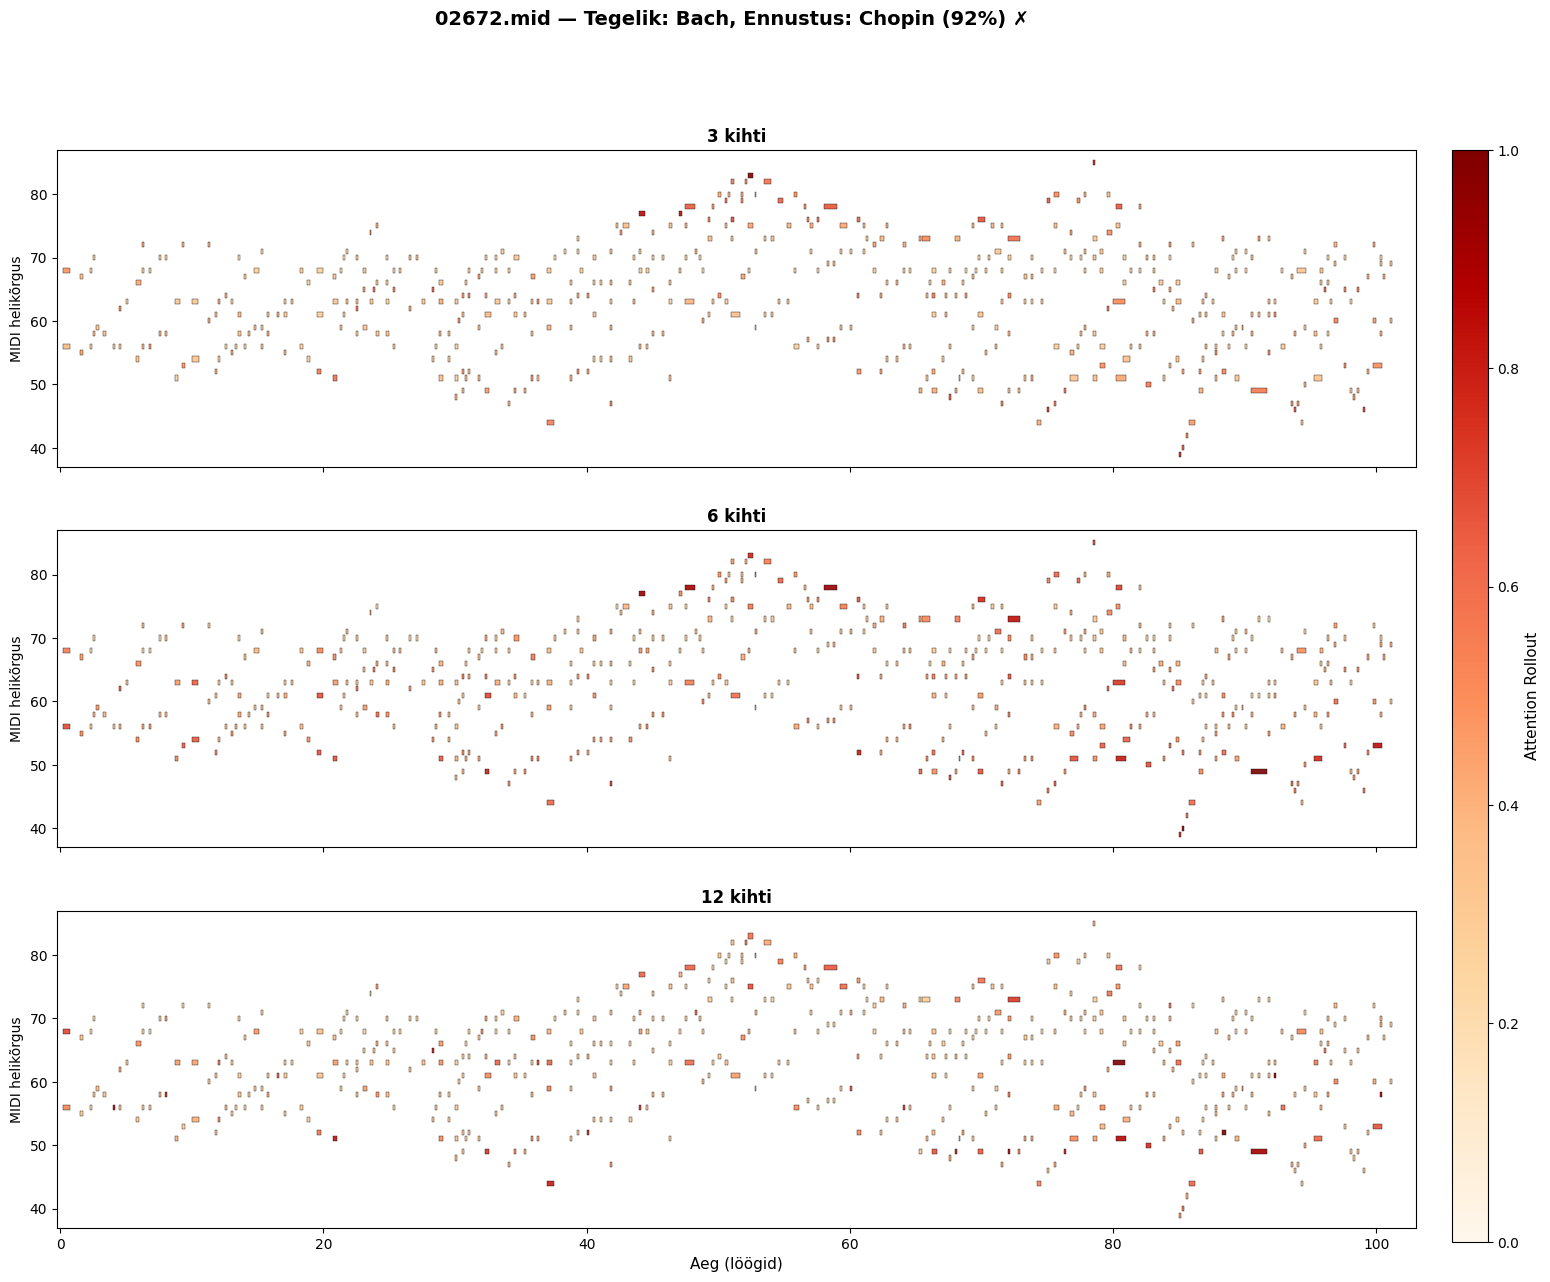

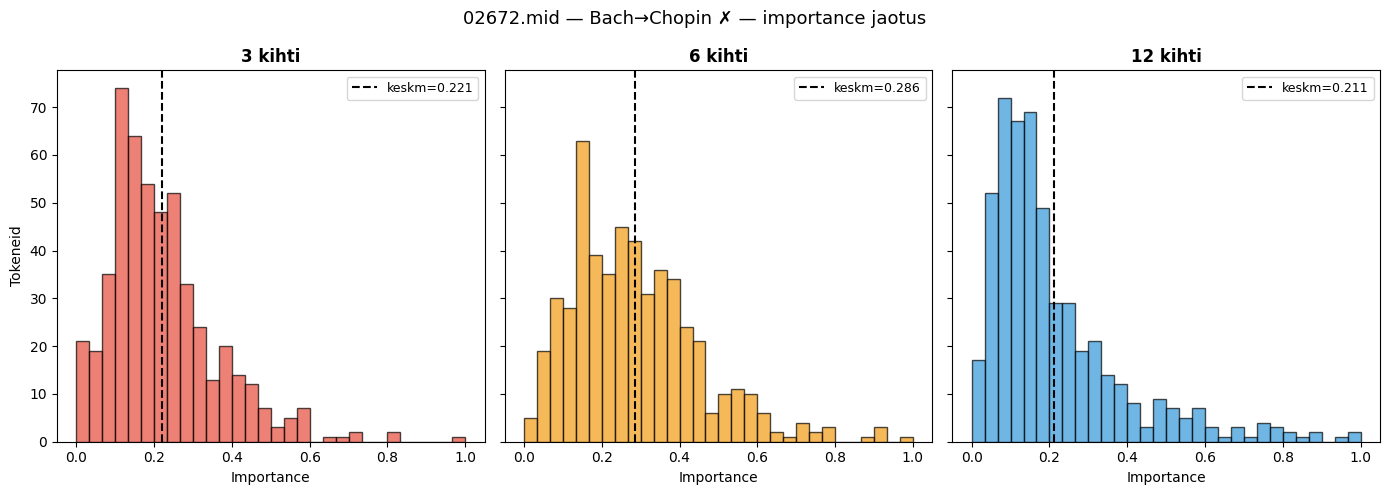

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/02672_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/02672_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/02672_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

EKSIMUS: 09909.mid — Ennustas Mozart 96.1%
Tegelik: Chopin


100%|██████████| 1/1 [00:00<00:00,  1.39it/s]


Ennustus: Mozart (96.1%)
      Bach:   2.4% 
    Mozart:  96.1% ████████████████████████████
    Chopin:   0.4% 
   Debussy:   1.1% 
Tokeneid (mitte-PAD): 175


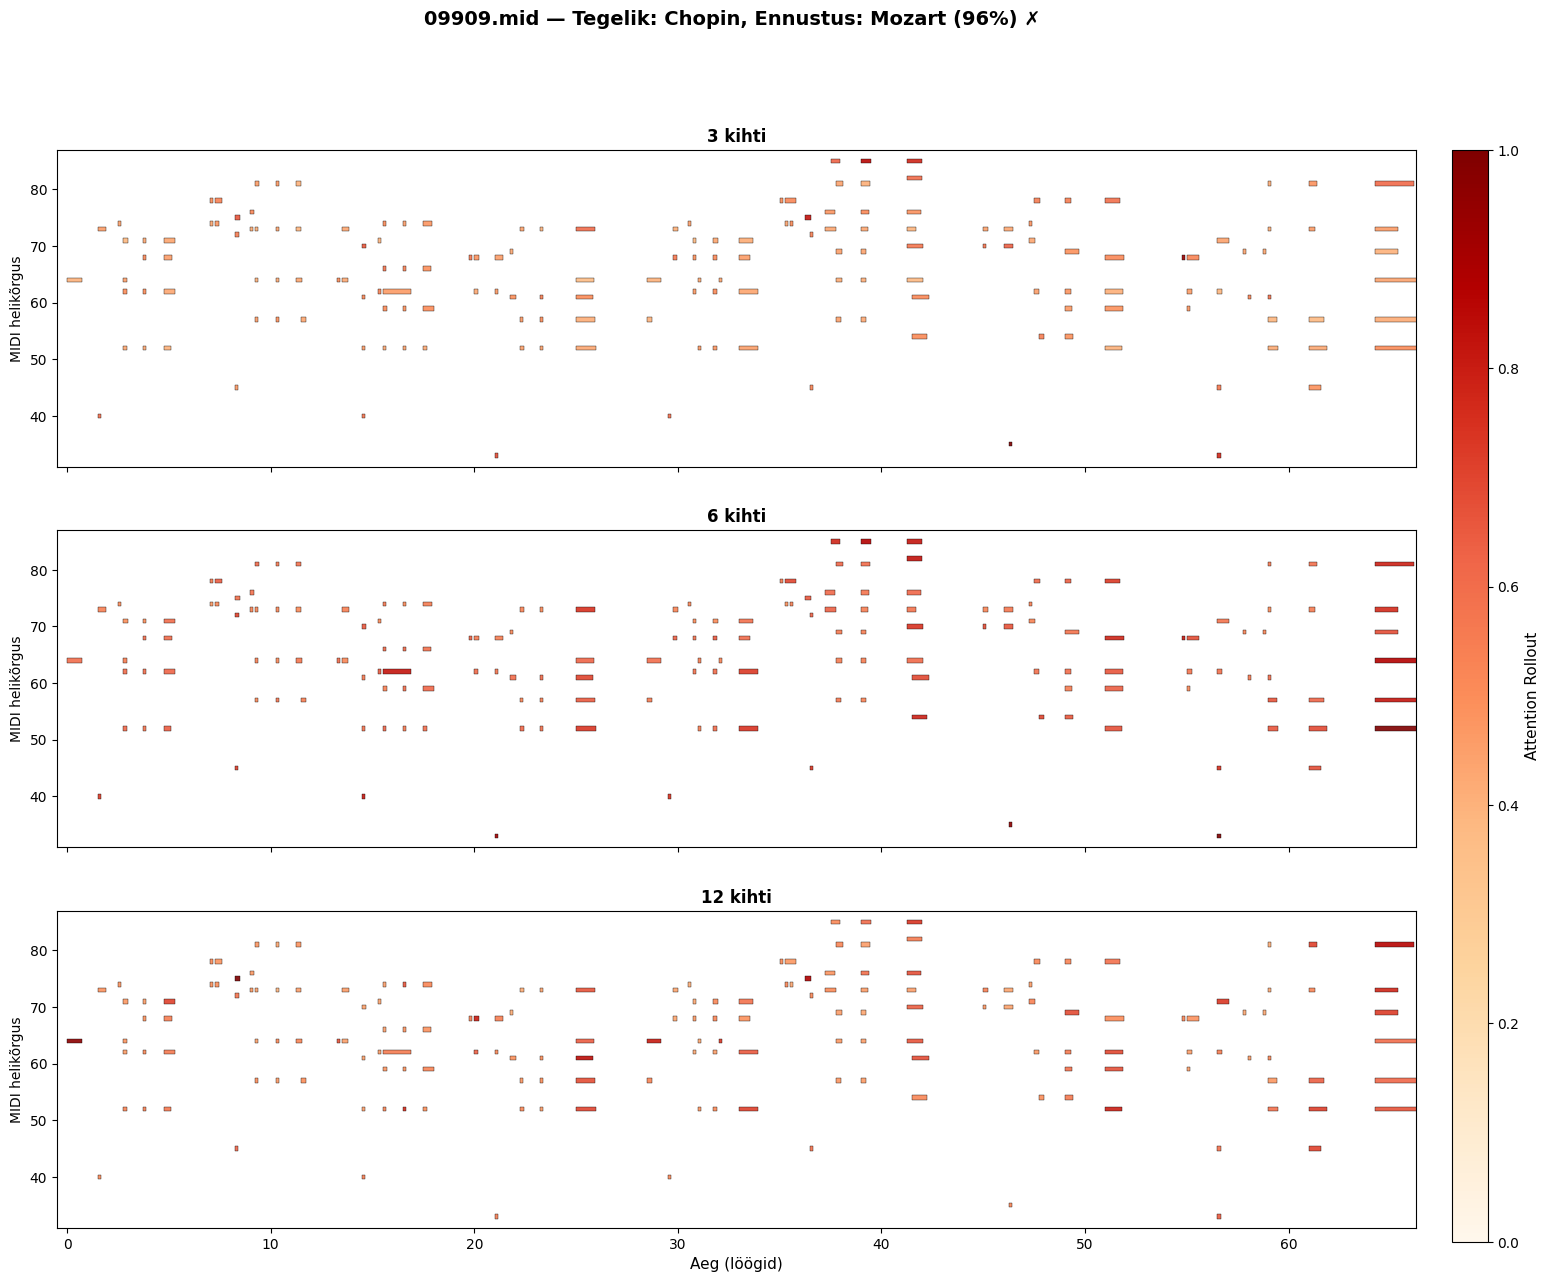

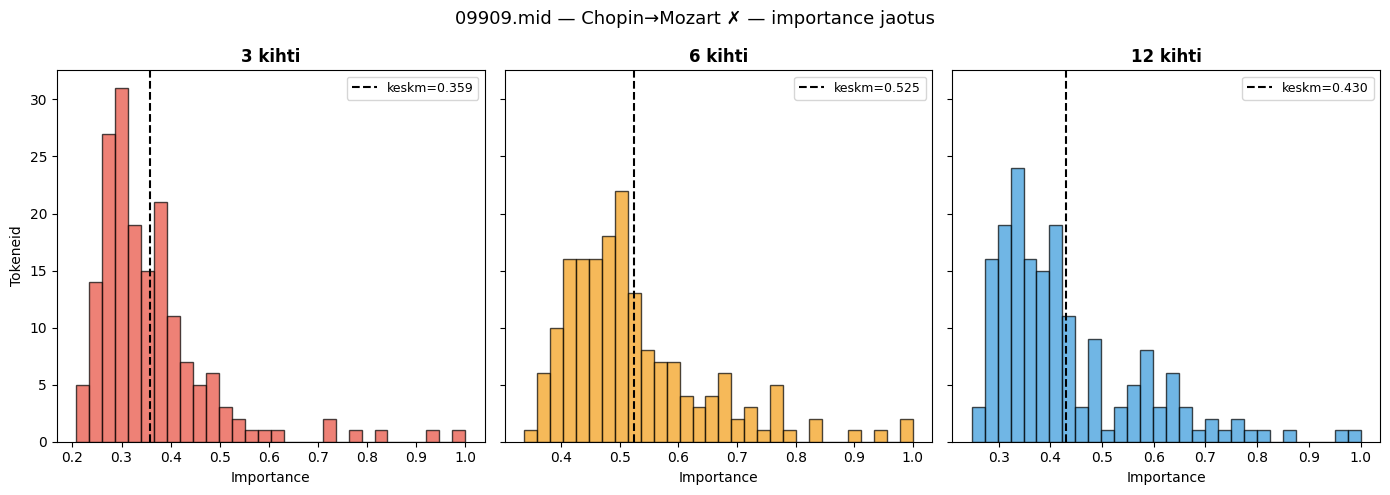

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09909_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09909_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09909_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

EKSIMUS: 09406.mid — Ennustas Debussy 73.8%
Tegelik: Chopin


100%|██████████| 1/1 [00:01<00:00,  1.31s/it]


Ennustus: Chopin (74.1%)
      Bach:   0.0% 
    Mozart:   0.0% 
    Chopin:  74.1% ██████████████████████
   Debussy:  25.9% ███████
Tokeneid (mitte-PAD): 512


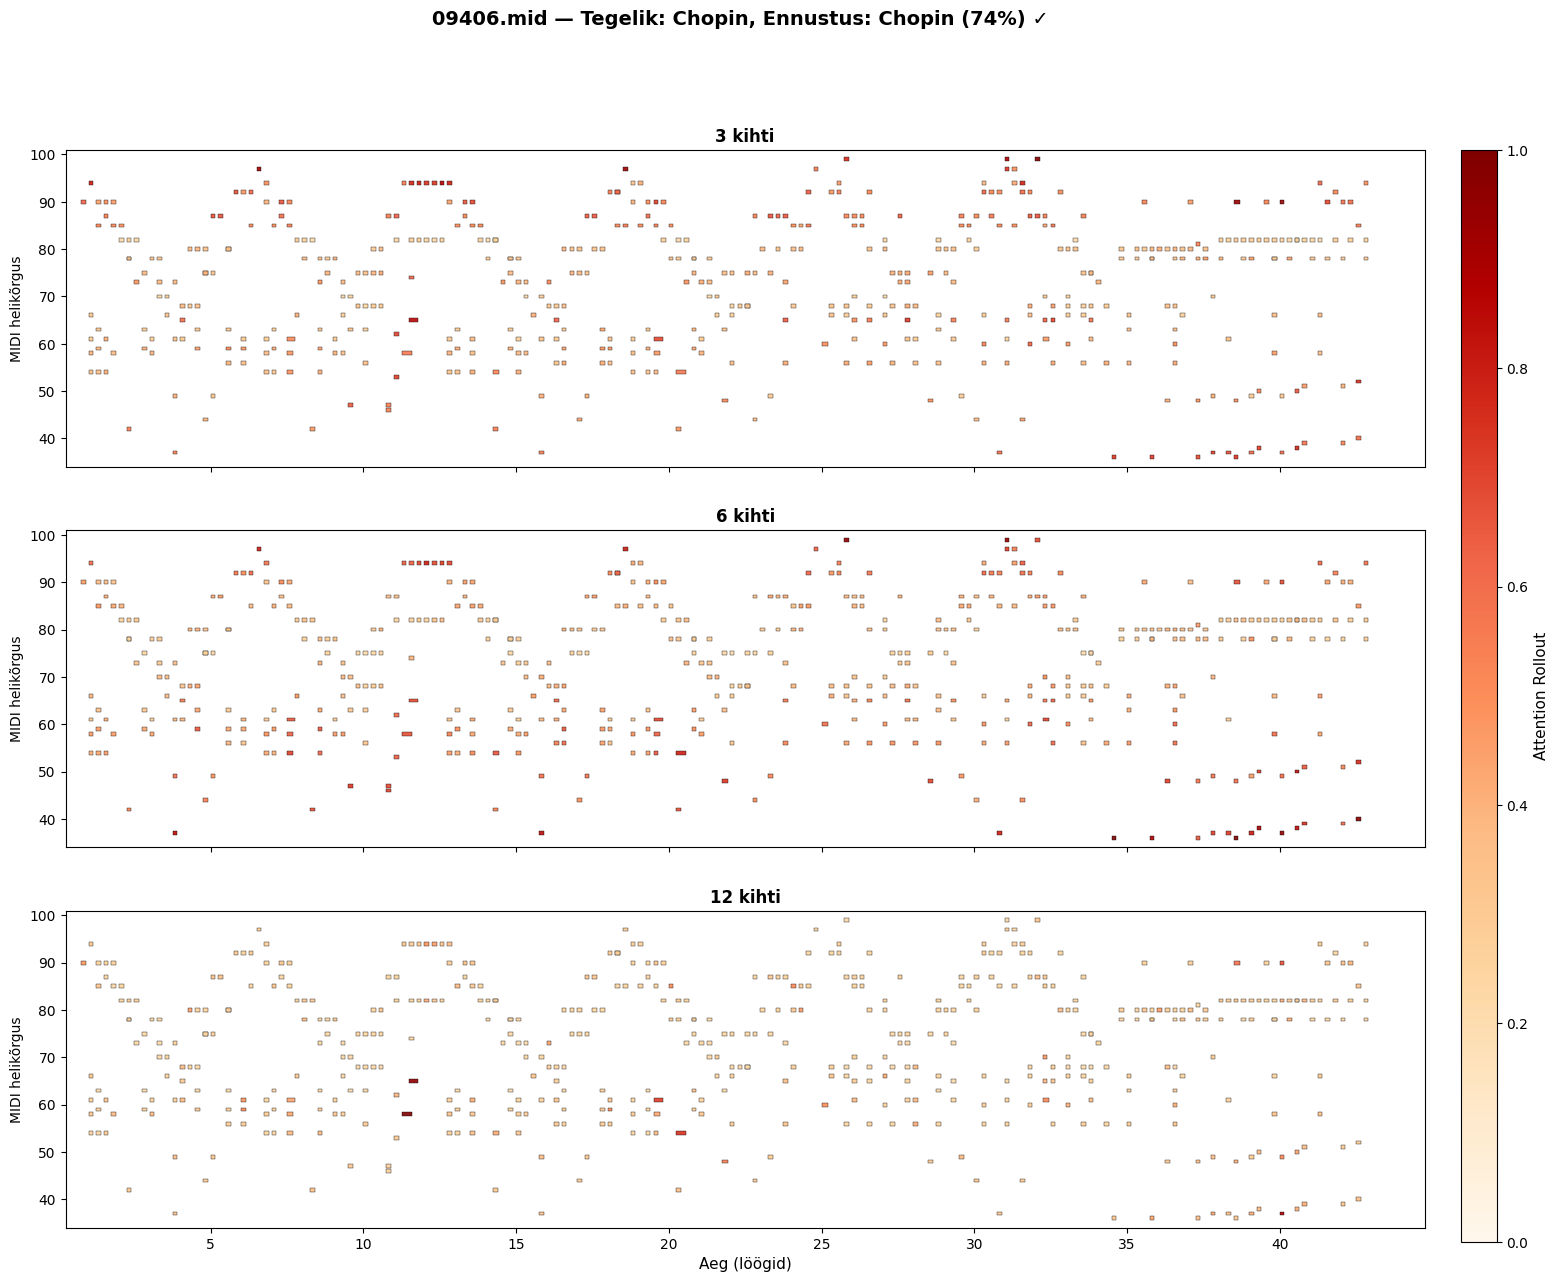

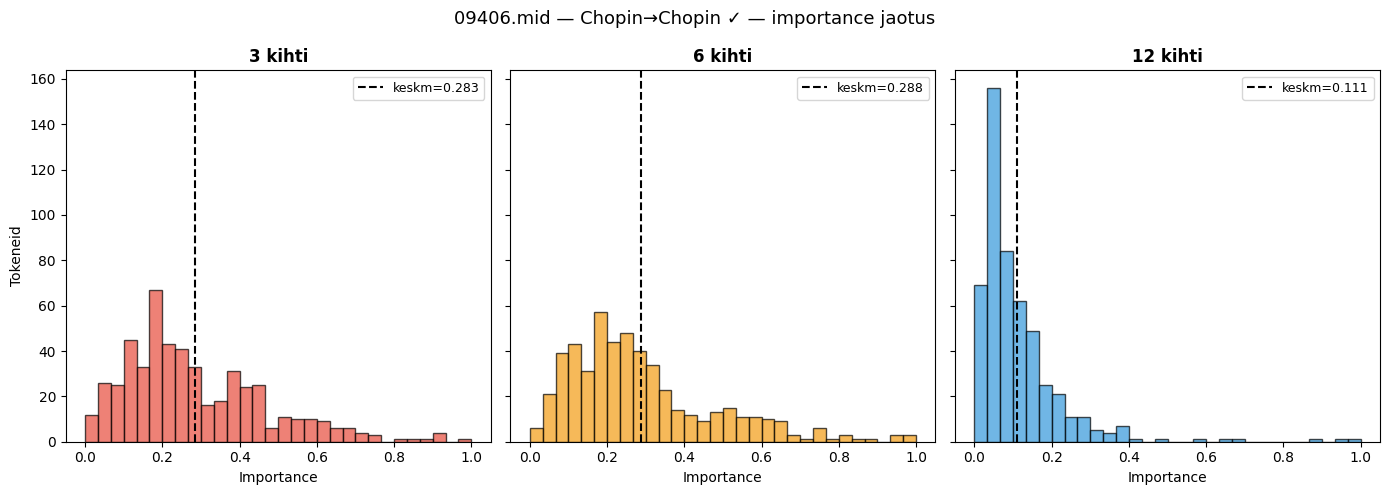

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09406_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09406_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09406_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

EKSIMUS: 05786.mid — Ennustas Bach 63.2%
Tegelik: Mozart


100%|██████████| 1/1 [00:01<00:00,  1.00s/it]


Ennustus: Mozart (50.3%)
      Bach:  49.6% ██████████████
    Mozart:  50.3% ███████████████
    Chopin:   0.1% 
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512


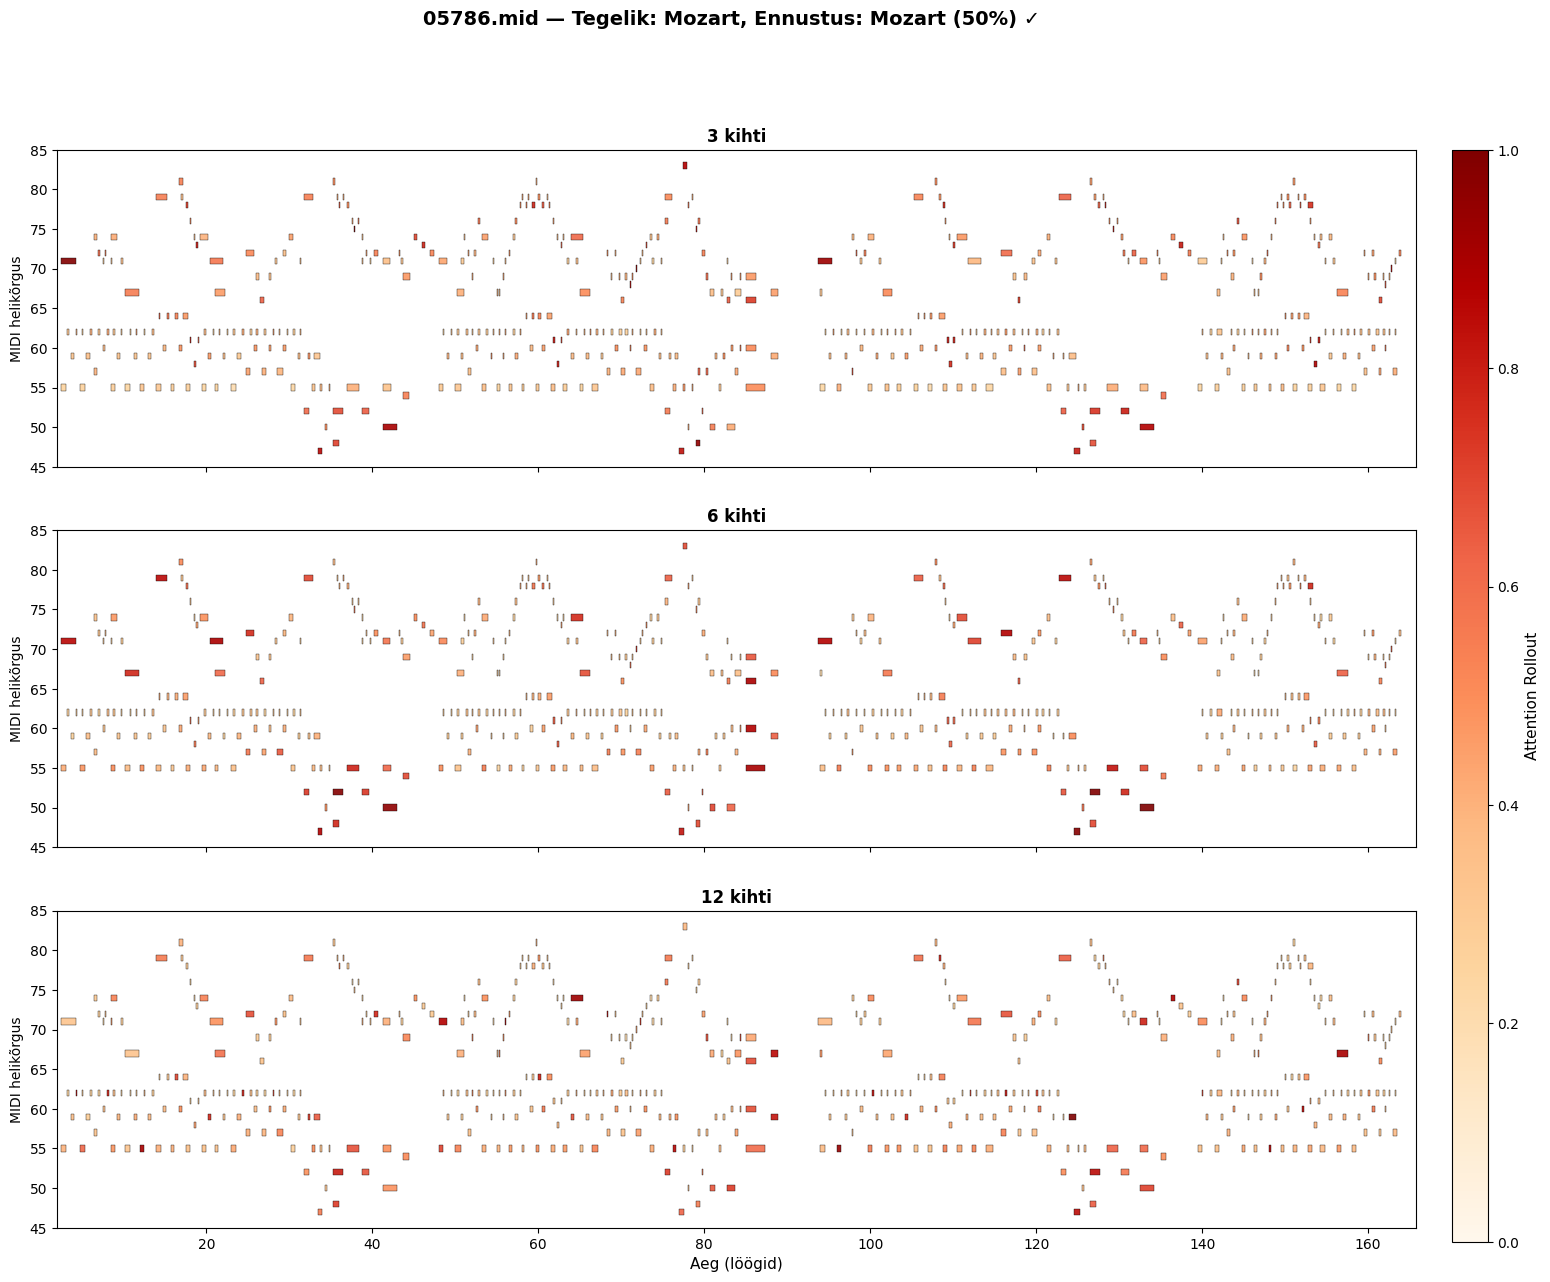

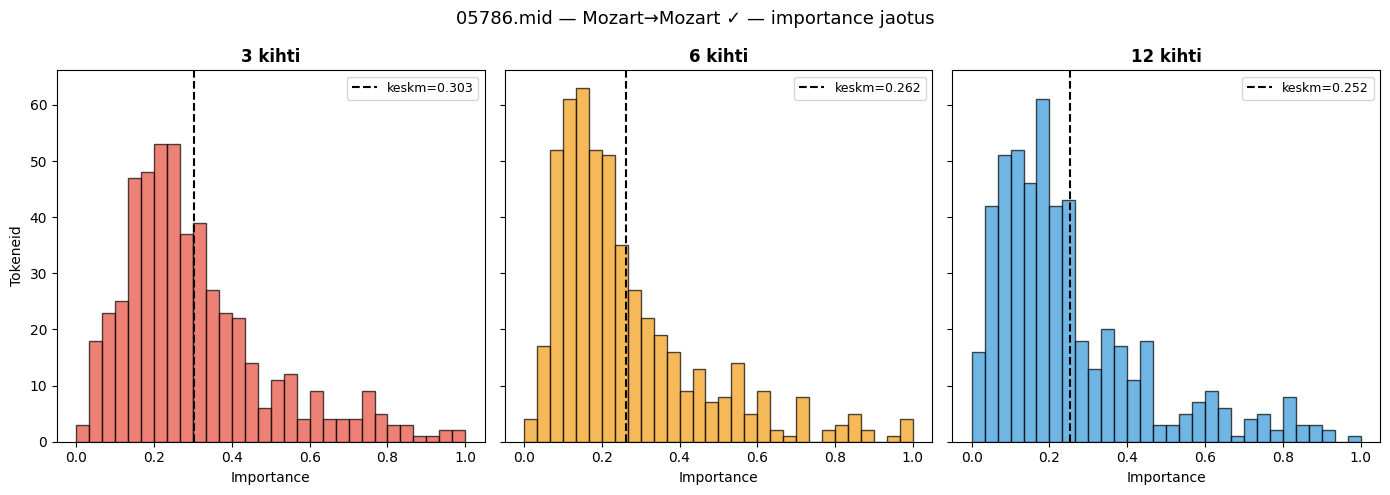

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/05786_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/05786_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/05786_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

EKSIMUS: 03003.mid — Ennustas Chopin 64.1%
Tegelik: Debussy


100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


Ennustus: Mozart (48.6%)
      Bach:   3.2% 
    Mozart:  48.6% ██████████████
    Chopin:  18.3% █████
   Debussy:  29.8% ████████
Tokeneid (mitte-PAD): 512


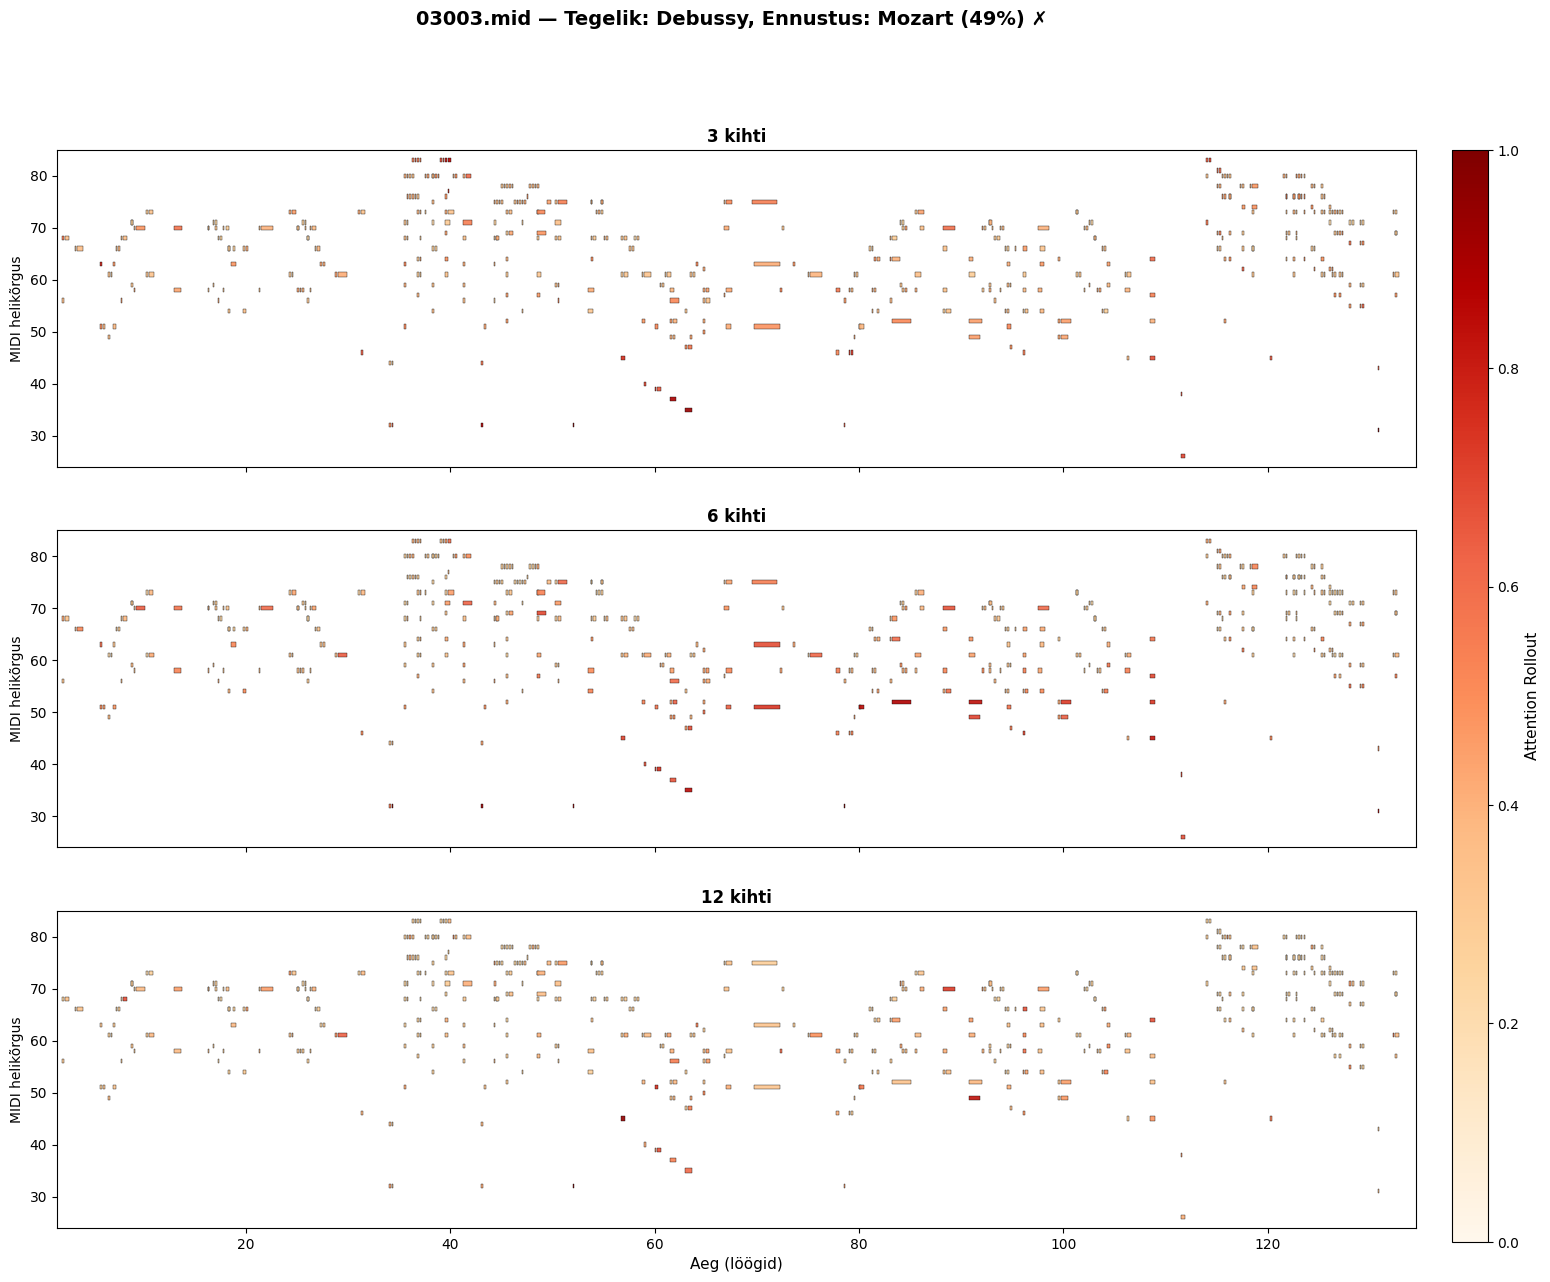

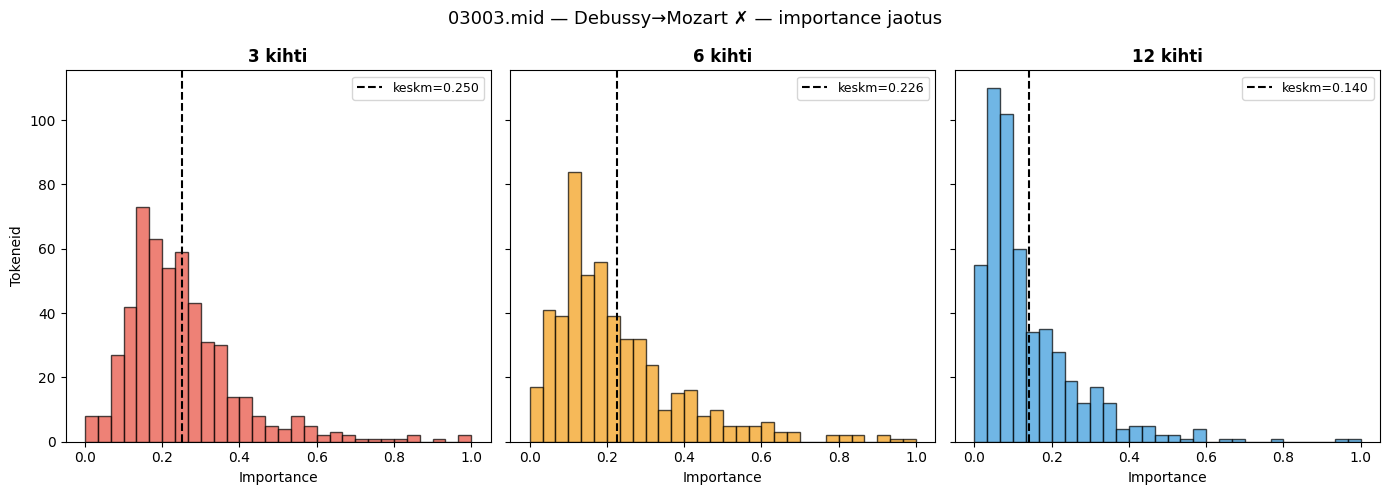

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/03003_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/03003_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/03003_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

EKSIMUS: 09787.mid — Ennustas Bach 52.0%
Tegelik: Chopin


100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


Ennustus: Bach (52.0%)
      Bach:  52.0% ███████████████
    Mozart:   1.4% 
    Chopin:  24.3% ███████
   Debussy:  22.2% ██████
Tokeneid (mitte-PAD): 484


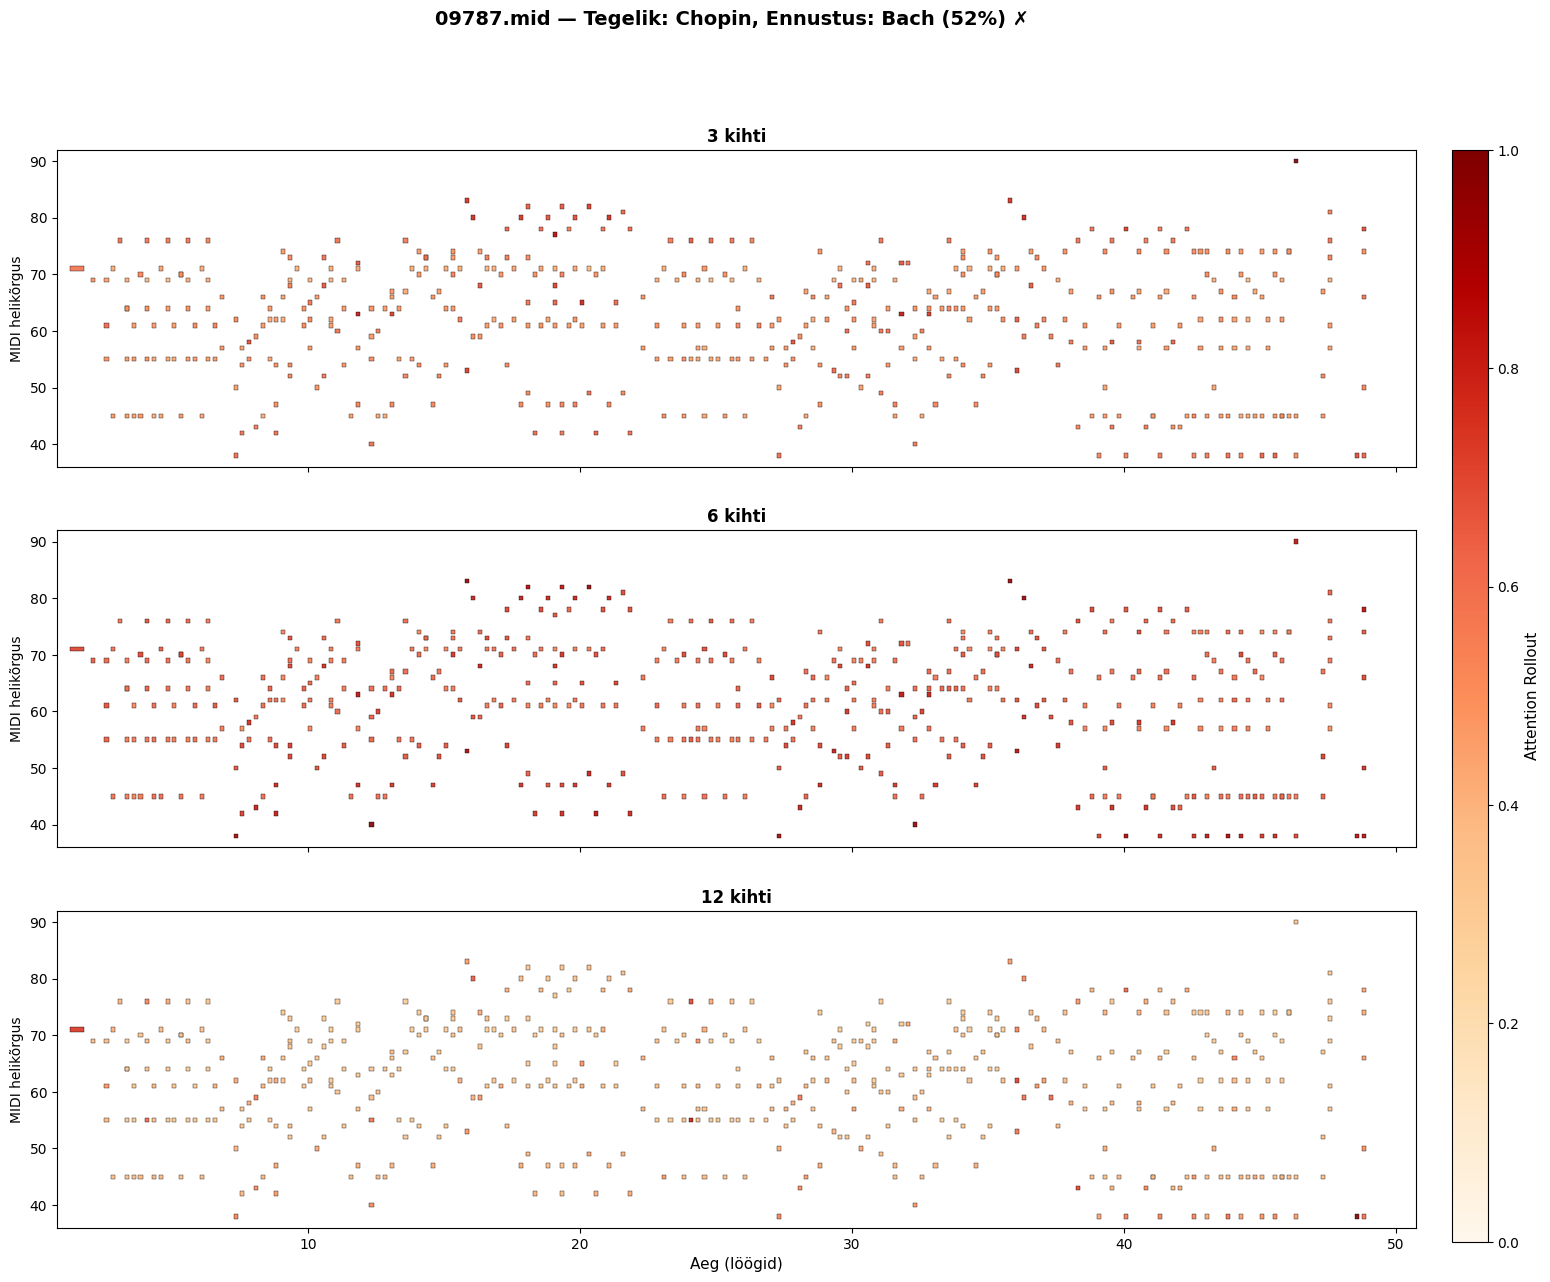

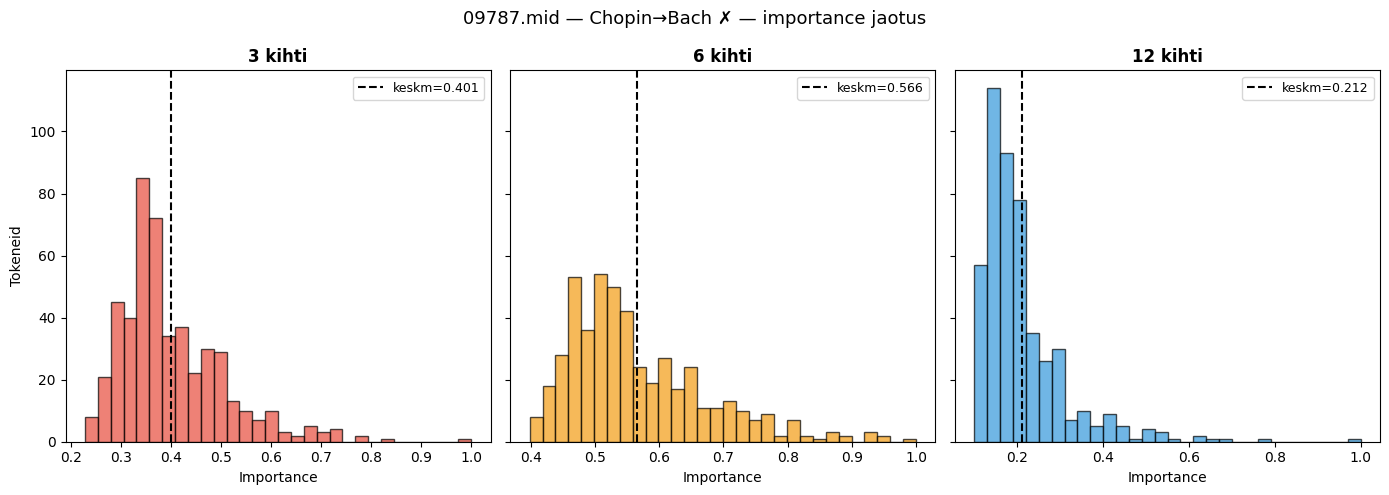

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09787_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09787_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav/09787_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]


Eksimuspalad salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/huvitav


######################################################################
KONTROLLGRUPP: KÕRGE KINDLUSEGA ÕIGED ENNUSTUSED
######################################################################

ÕIGE: 02177.mid — 100.0% kindlus
Helilooja: Bach


100%|██████████| 1/1 [00:00<00:00,  1.37it/s]


Ennustus: Bach (100.0%)
      Bach: 100.0% █████████████████████████████
    Mozart:   0.0% 
    Chopin:   0.0% 
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512


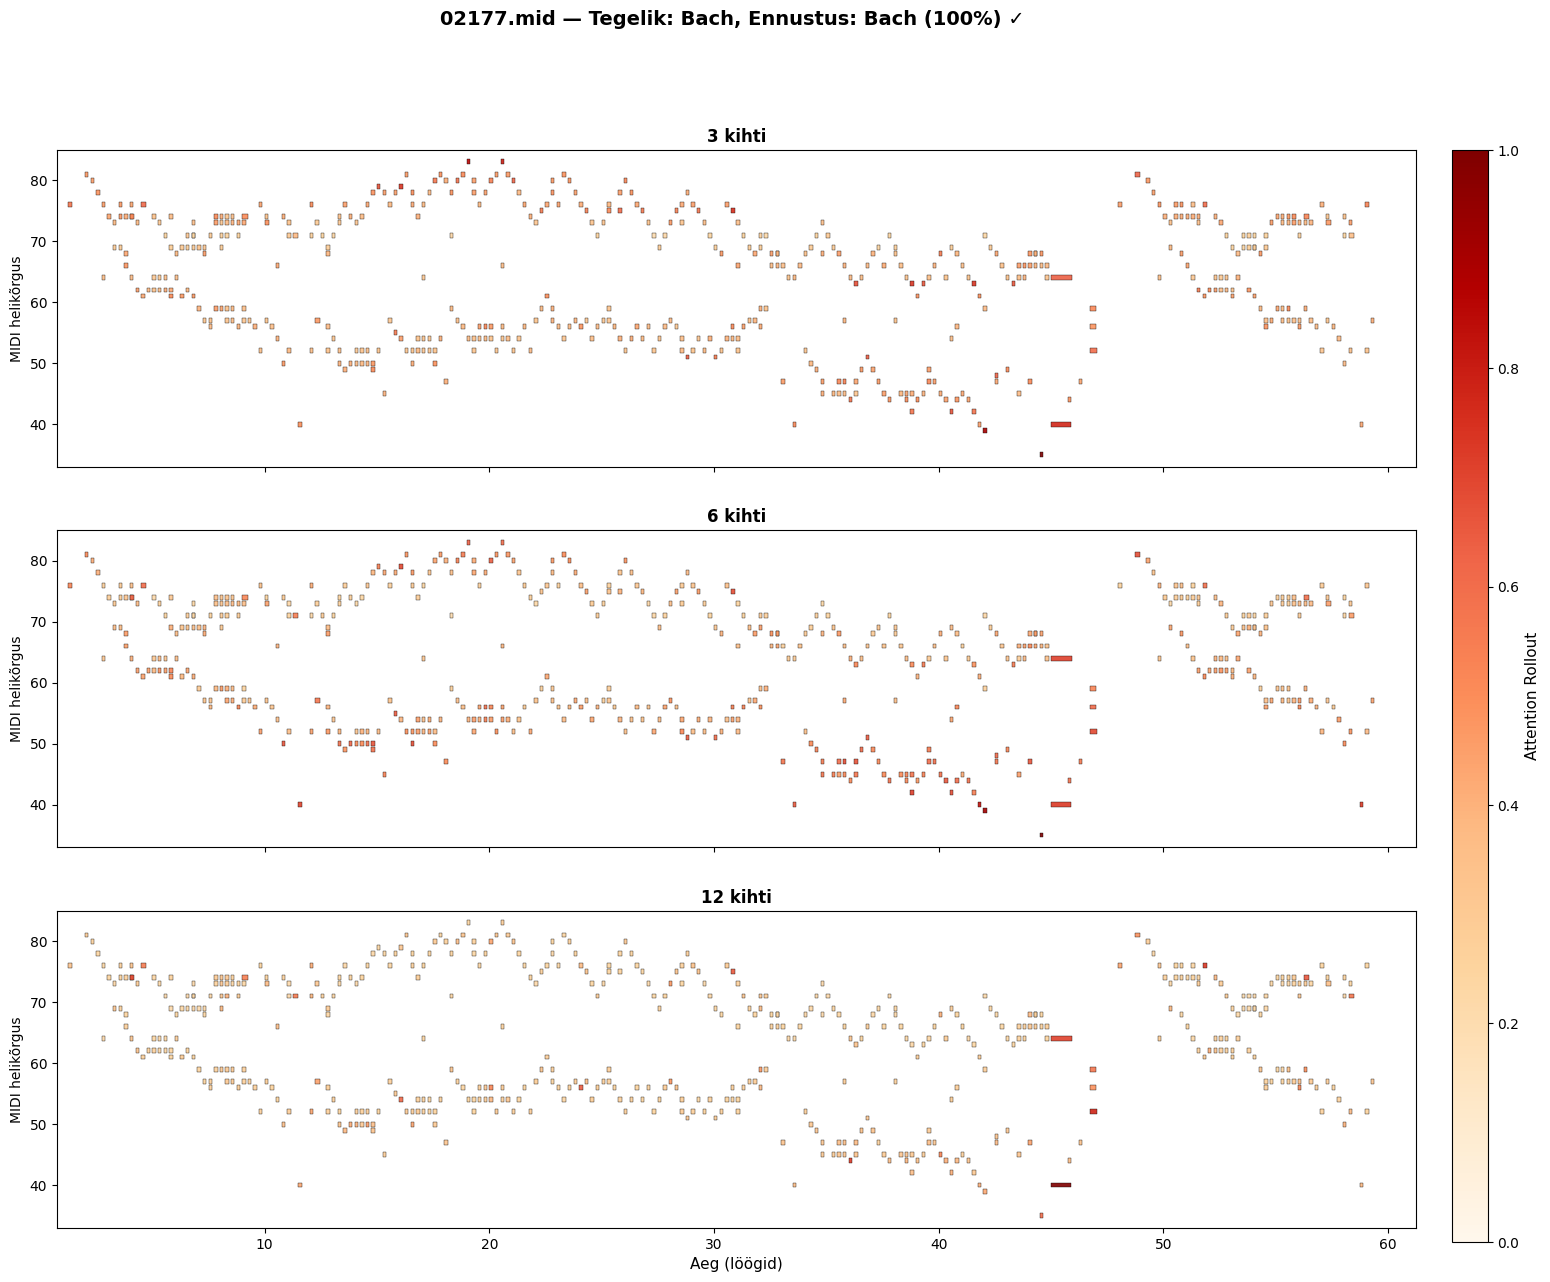

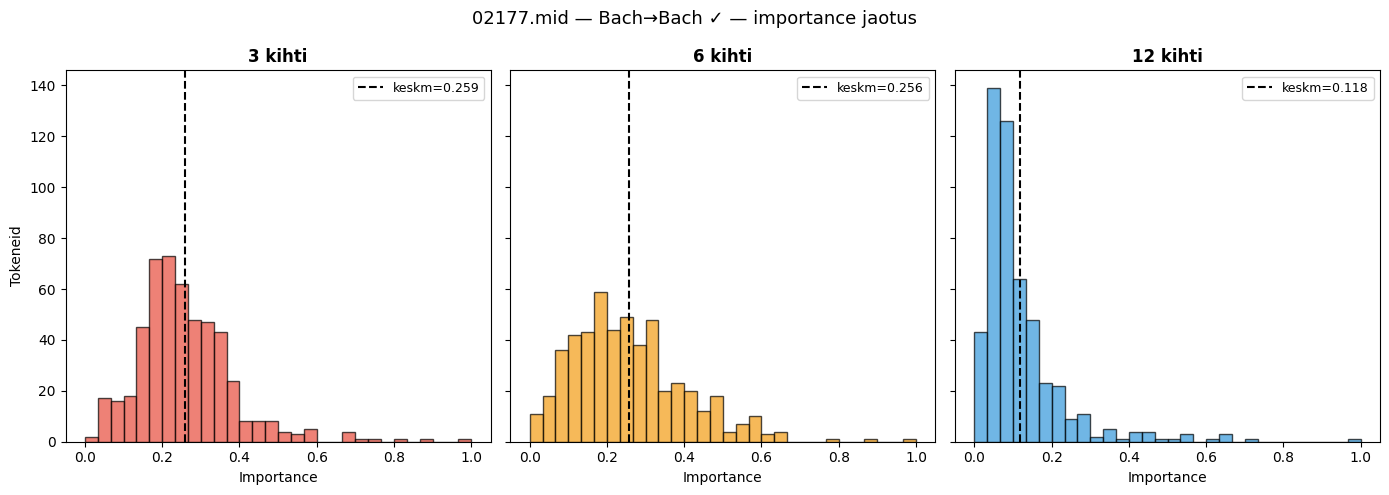

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/02177_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/02177_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/02177_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

ÕIGE: 01911.mid — 100.0% kindlus
Helilooja: Bach


100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


Ennustus: Bach (100.0%)
      Bach: 100.0% █████████████████████████████
    Mozart:   0.0% 
    Chopin:   0.0% 
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512


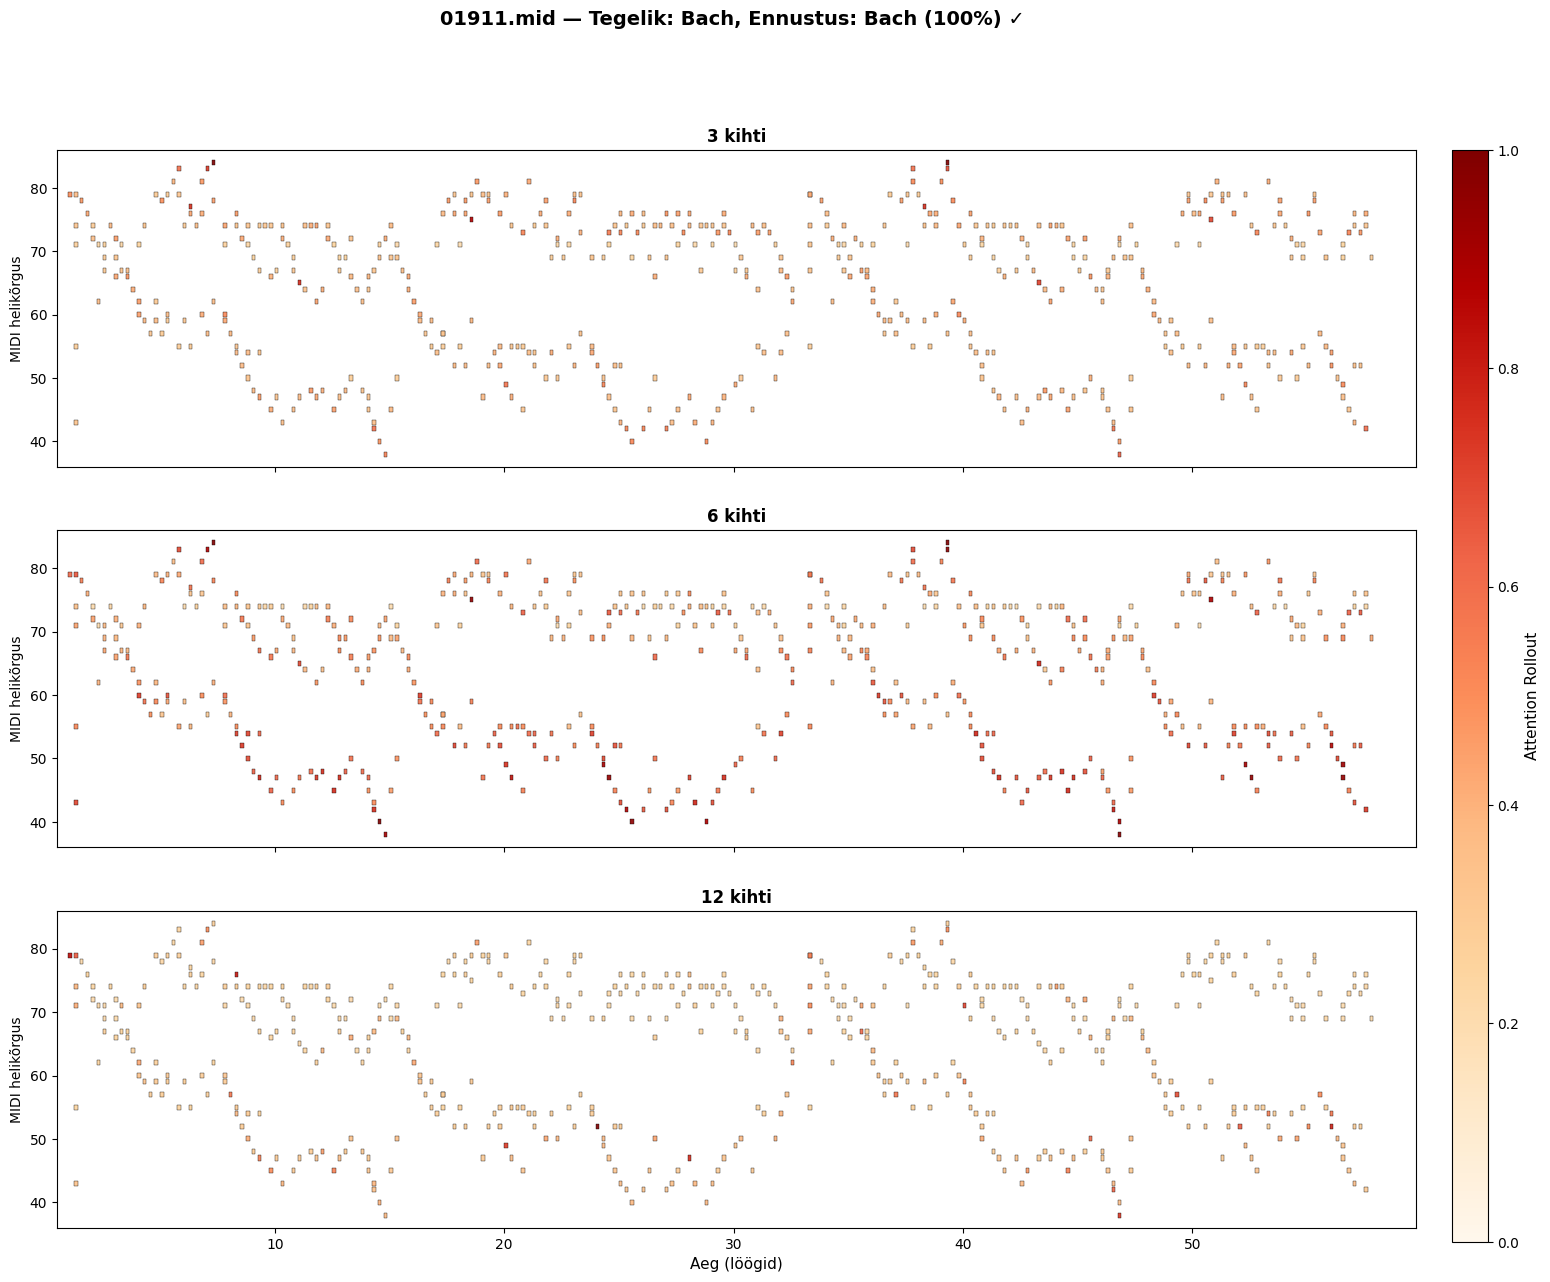

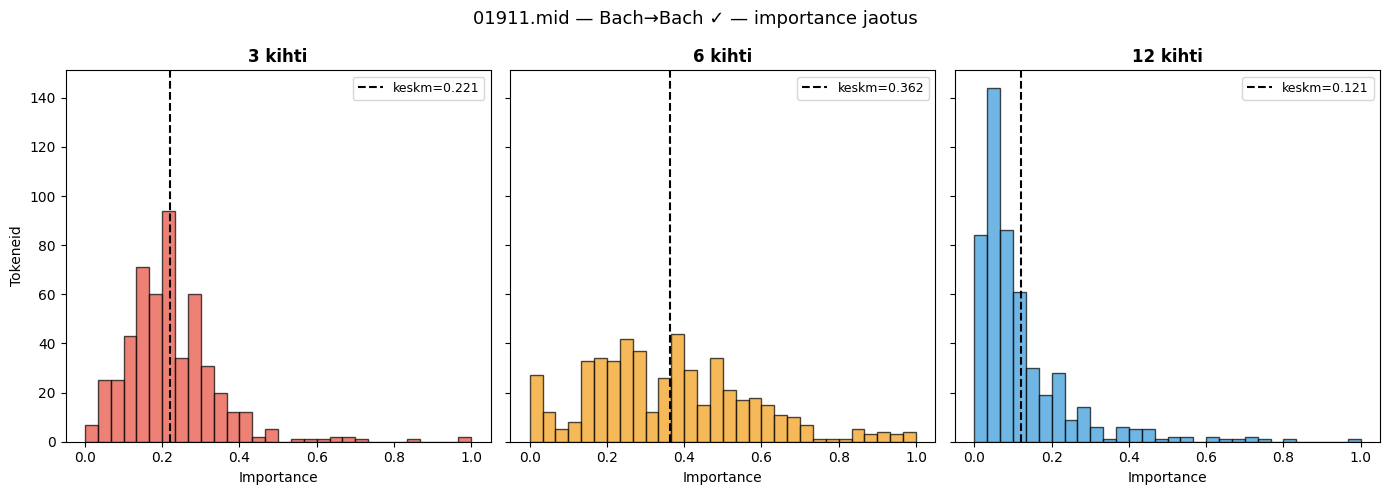

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/01911_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/01911_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/01911_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

ÕIGE: 05225.mid — 99.8% kindlus
Helilooja: Mozart


100%|██████████| 1/1 [00:01<00:00,  1.17s/it]


Ennustus: Mozart (99.8%)
      Bach:   0.1% 
    Mozart:  99.8% █████████████████████████████
    Chopin:   0.0% 
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512


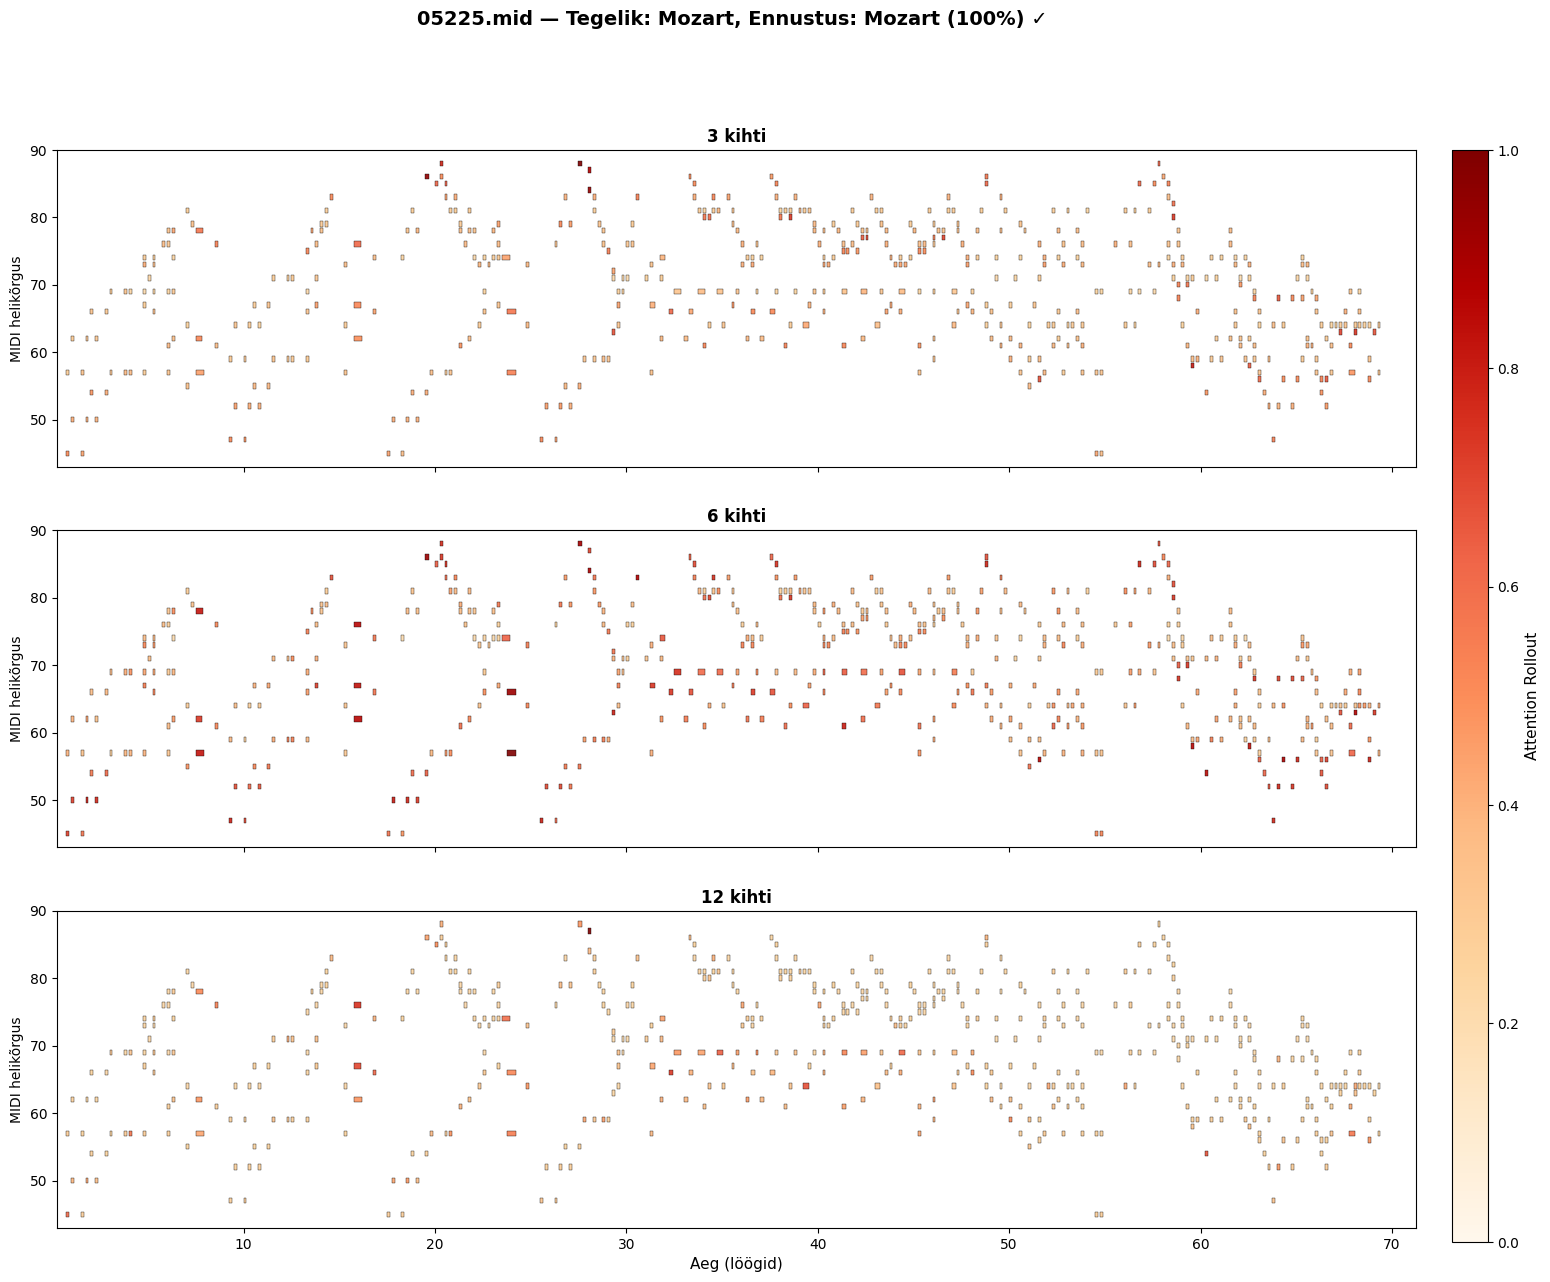

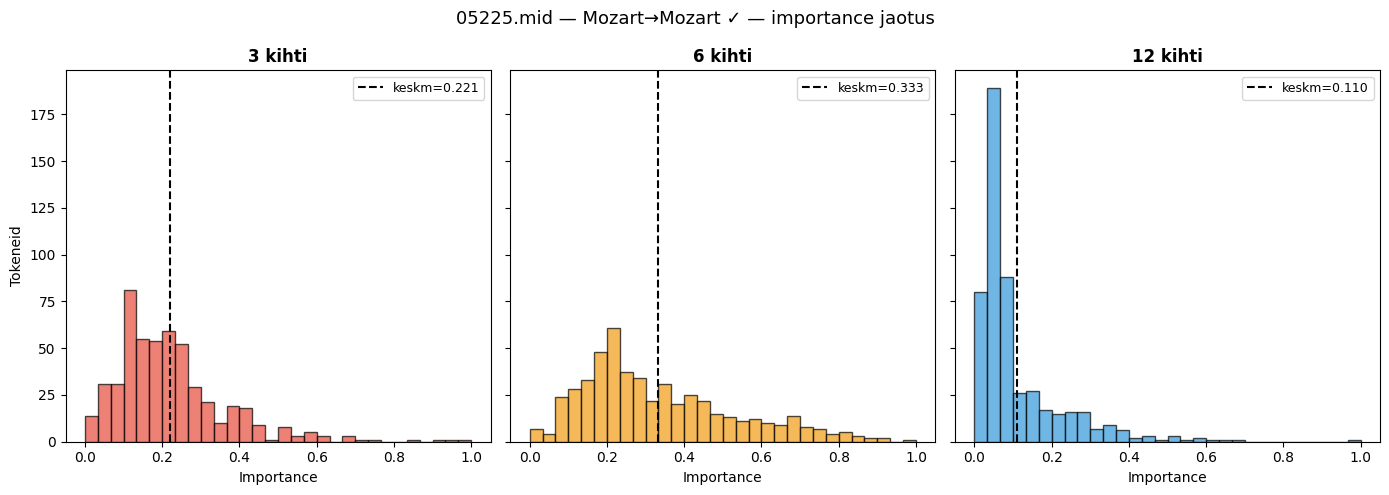

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/05225_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/05225_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/05225_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

ÕIGE: 10775.mid — 99.8% kindlus
Helilooja: Mozart


100%|██████████| 1/1 [00:01<00:00,  1.32s/it]


Ennustus: Mozart (99.5%)
      Bach:   0.3% 
    Mozart:  99.5% █████████████████████████████
    Chopin:   0.1% 
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512


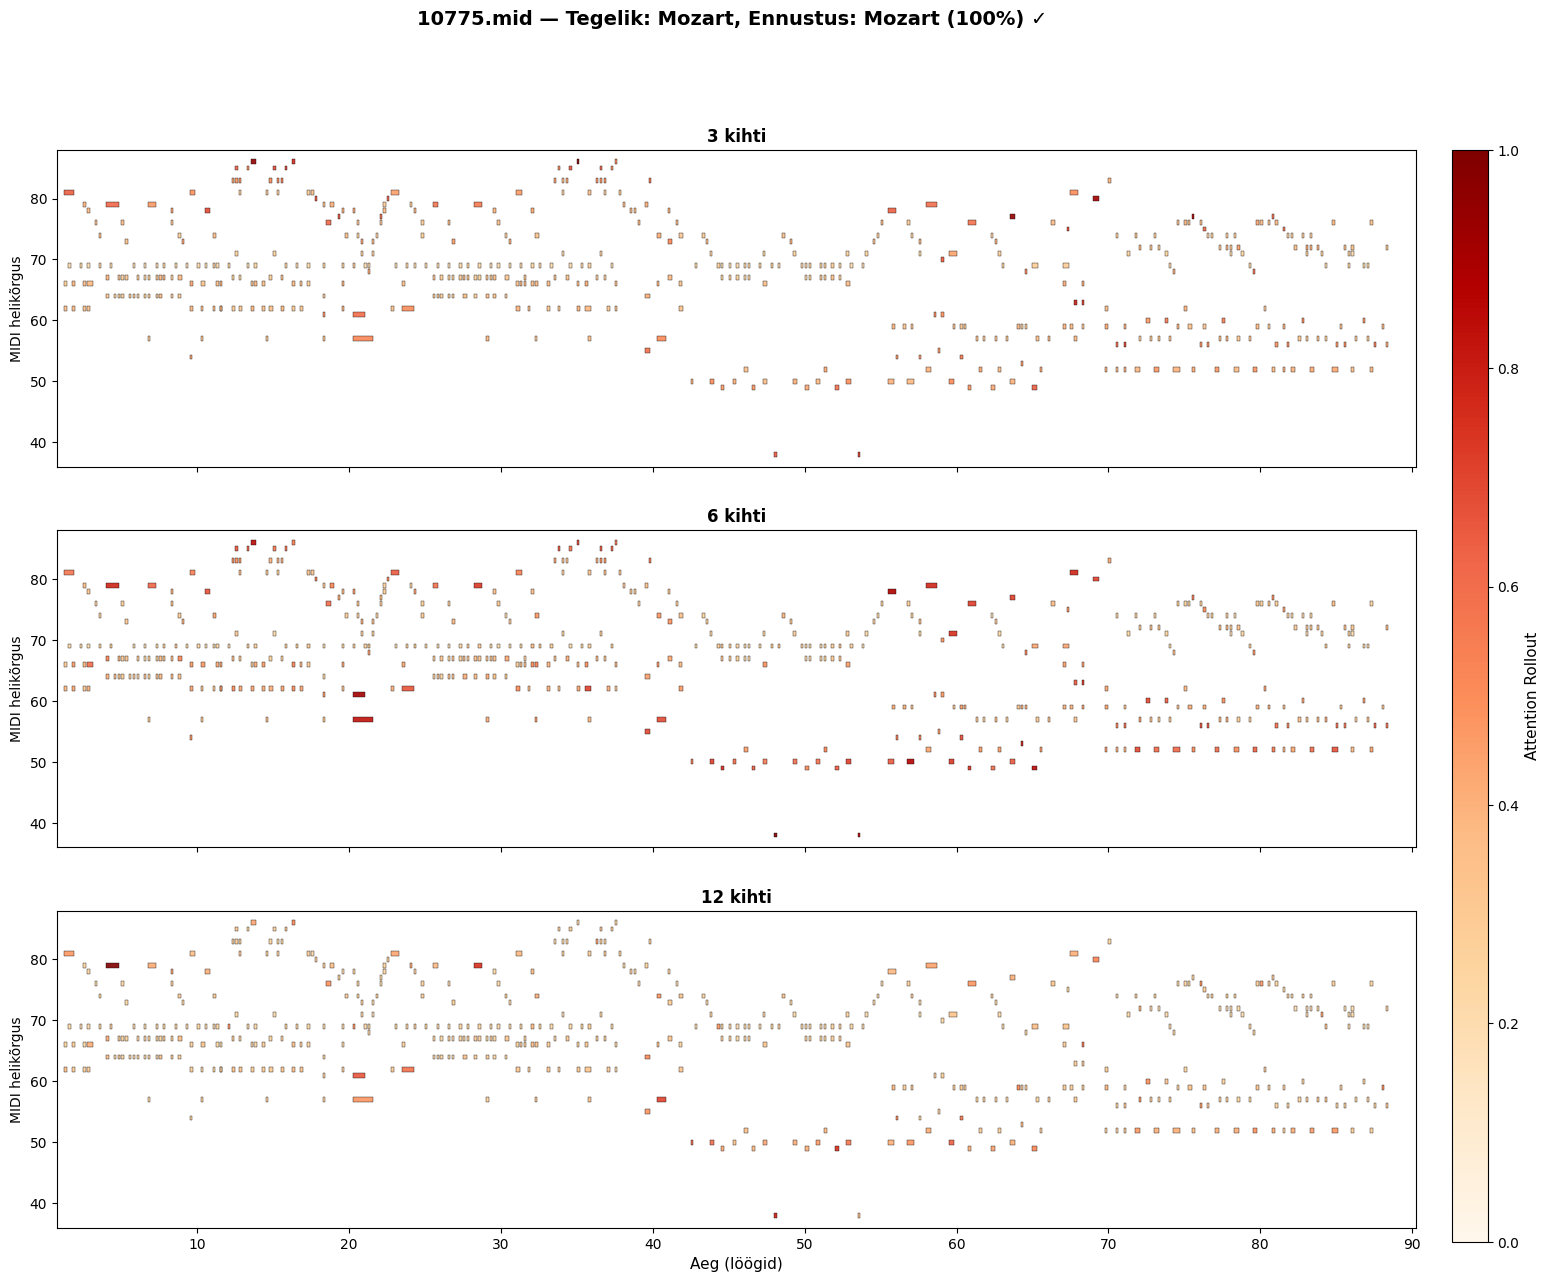

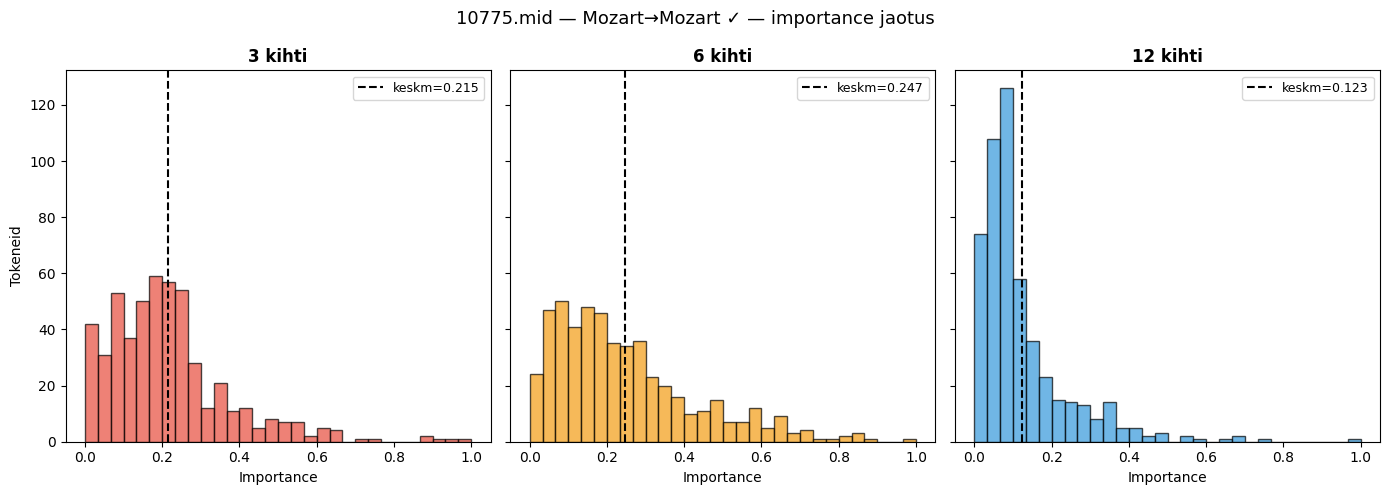

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/10775_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/10775_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/10775_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

ÕIGE: 09537.mid — 99.9% kindlus
Helilooja: Chopin


100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


Ennustus: Chopin (99.9%)
      Bach:   0.0% 
    Mozart:   0.0% 
    Chopin:  99.9% █████████████████████████████
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512


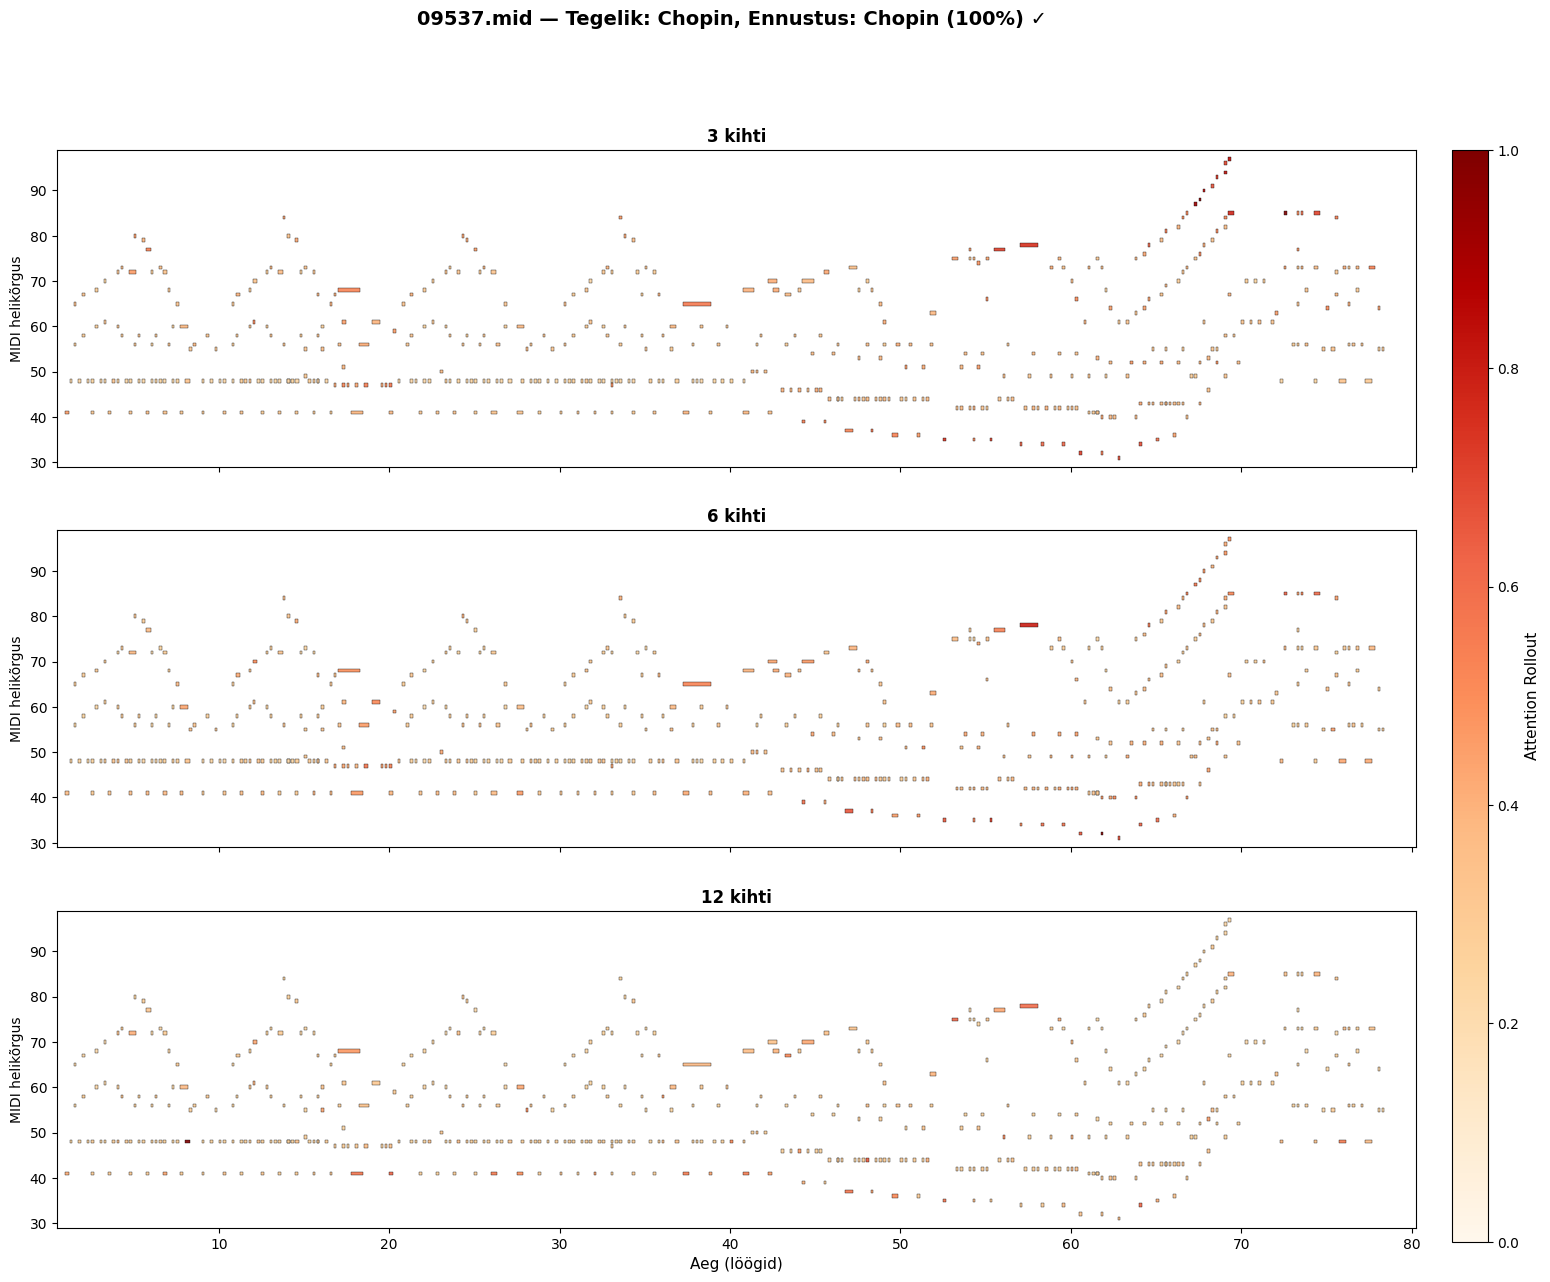

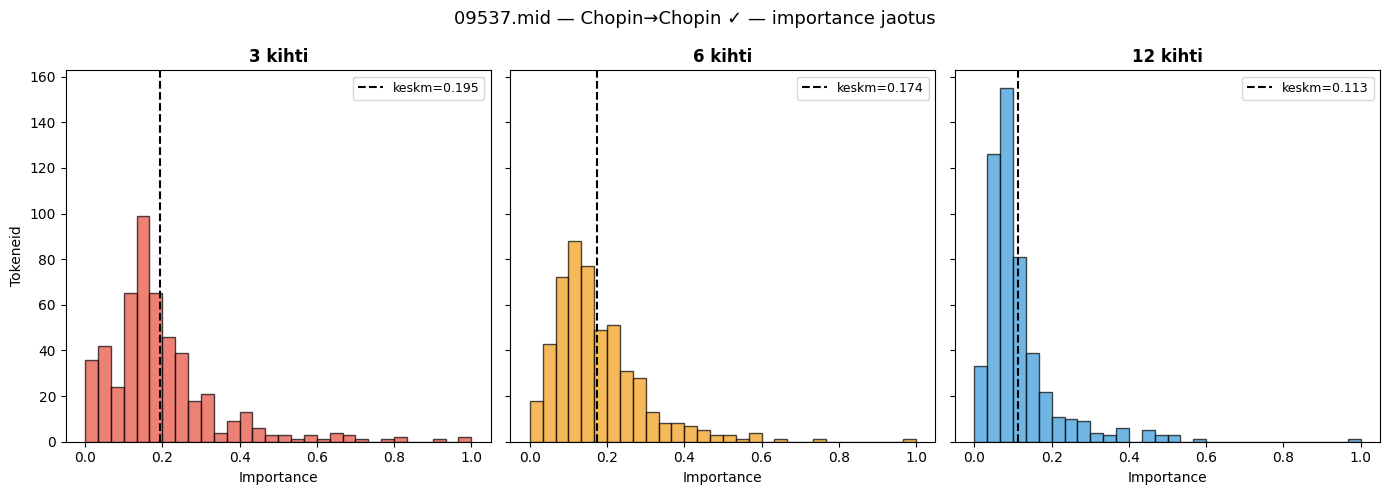

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/09537_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/09537_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/09537_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

ÕIGE: 11086.mid — 99.9% kindlus
Helilooja: Chopin


100%|██████████| 1/1 [00:01<00:00,  1.67s/it]


Ennustus: Chopin (100.0%)
      Bach:   0.0% 
    Mozart:   0.0% 
    Chopin: 100.0% █████████████████████████████
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512


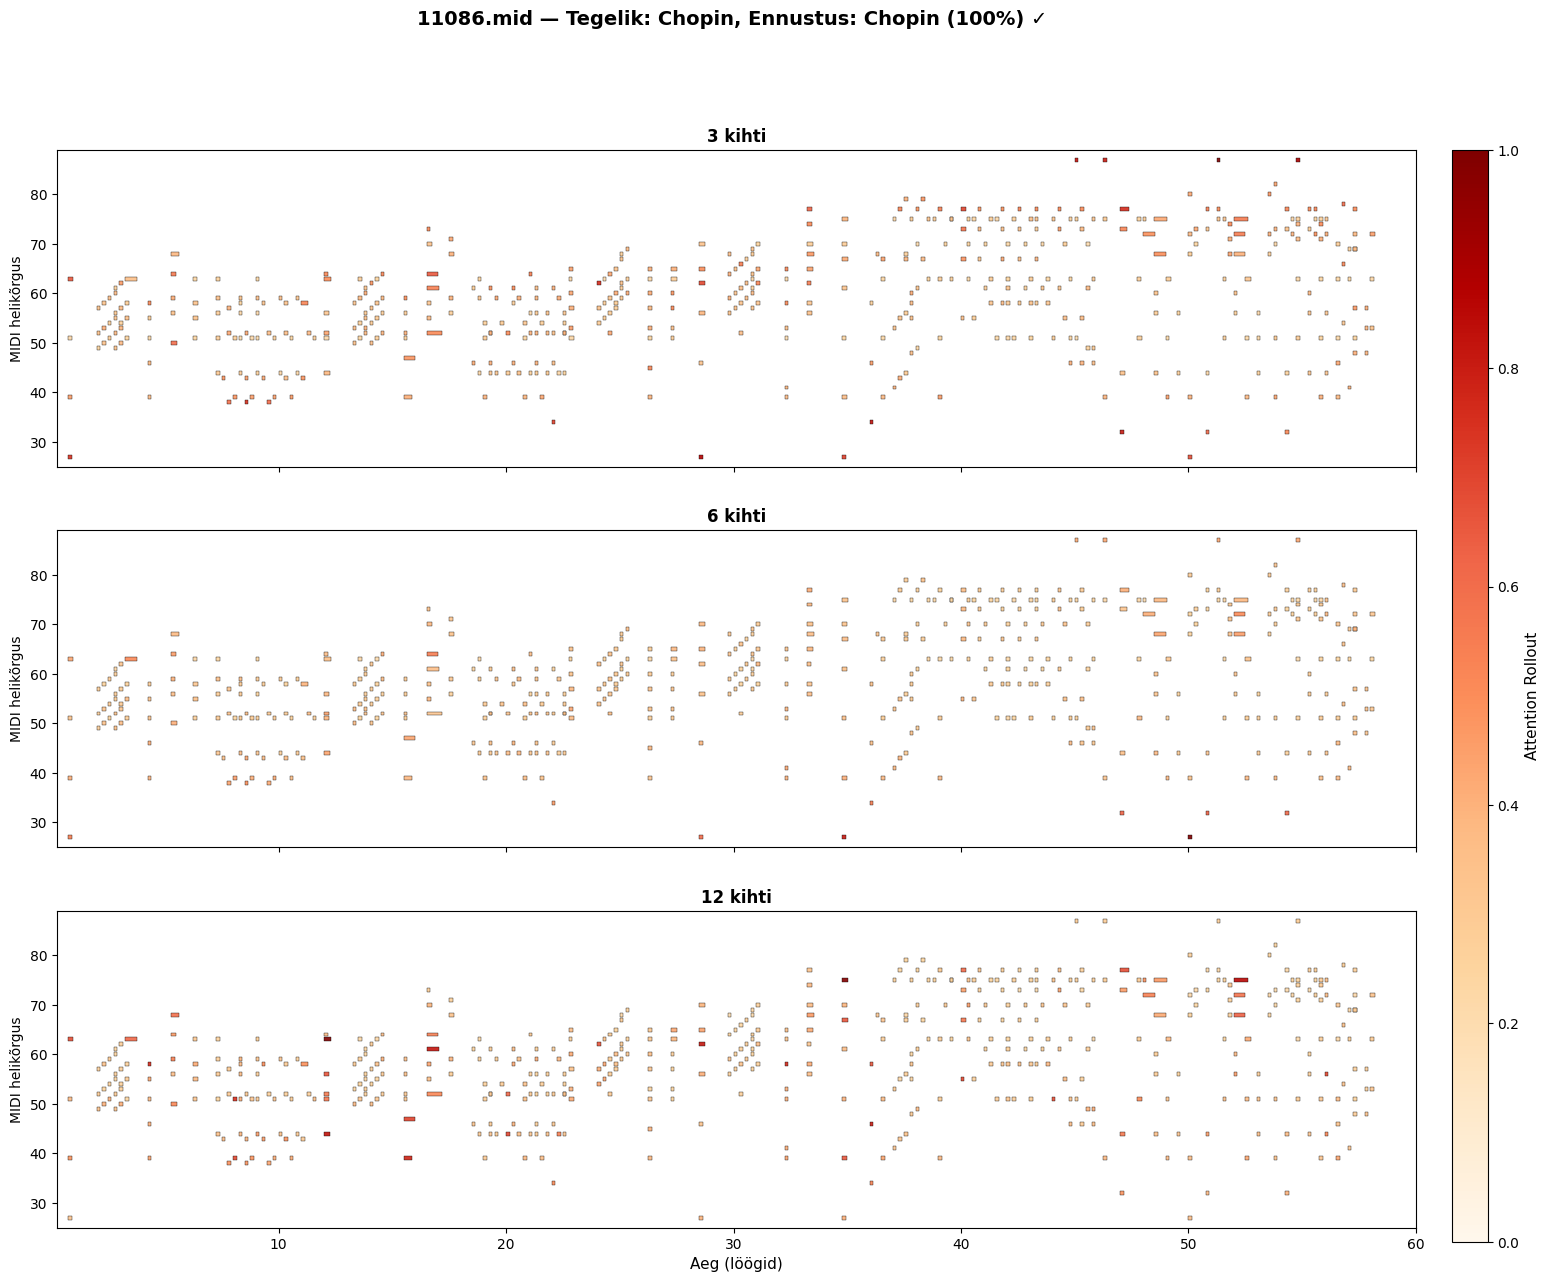

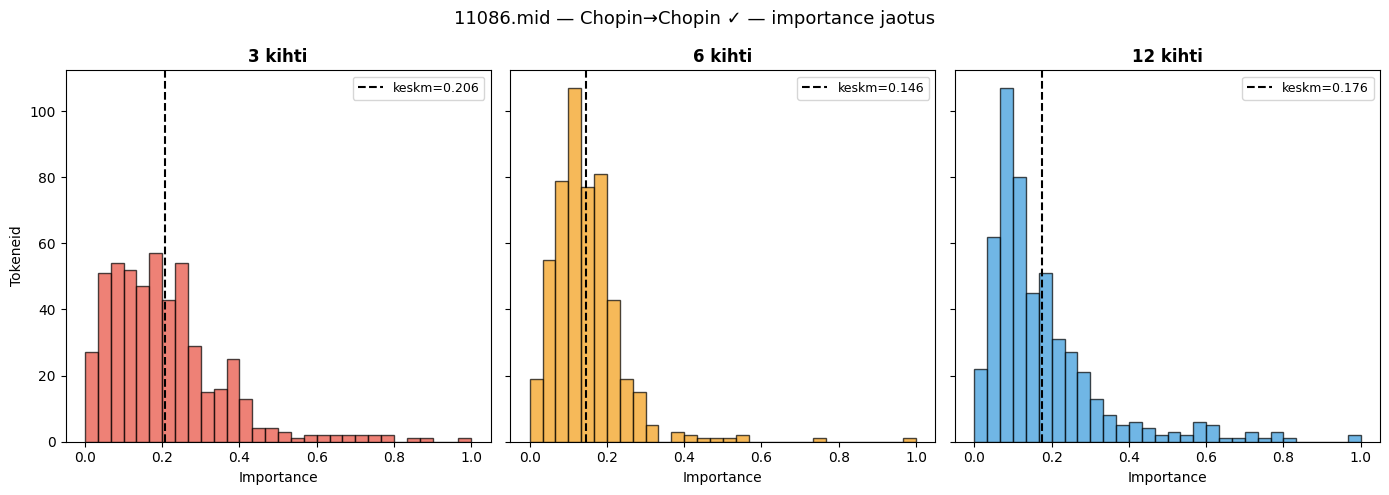

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/11086_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/11086_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/11086_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

ÕIGE: 03121.mid — 99.5% kindlus
Helilooja: Debussy


100%|██████████| 1/1 [00:00<00:00,  1.31it/s]


Ennustus: Debussy (99.2%)
      Bach:   0.0% 
    Mozart:   0.6% 
    Chopin:   0.2% 
   Debussy:  99.2% █████████████████████████████
Tokeneid (mitte-PAD): 512


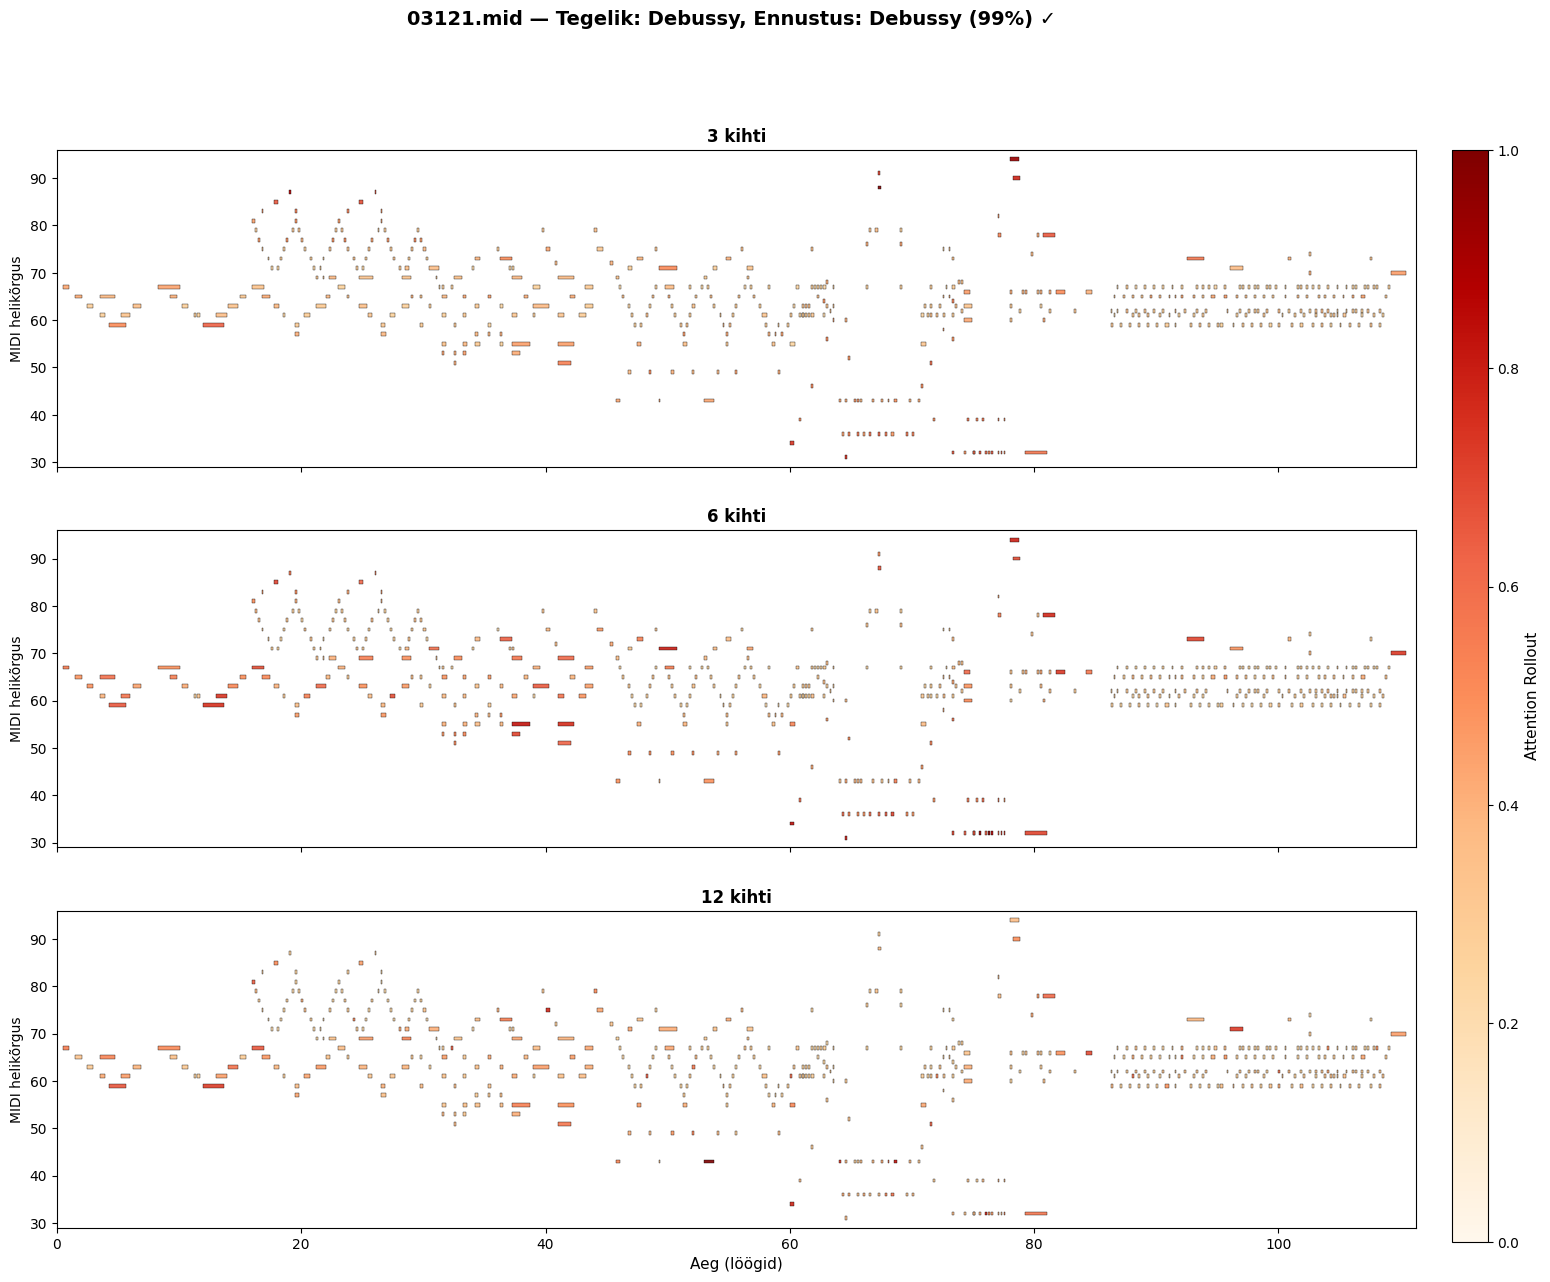

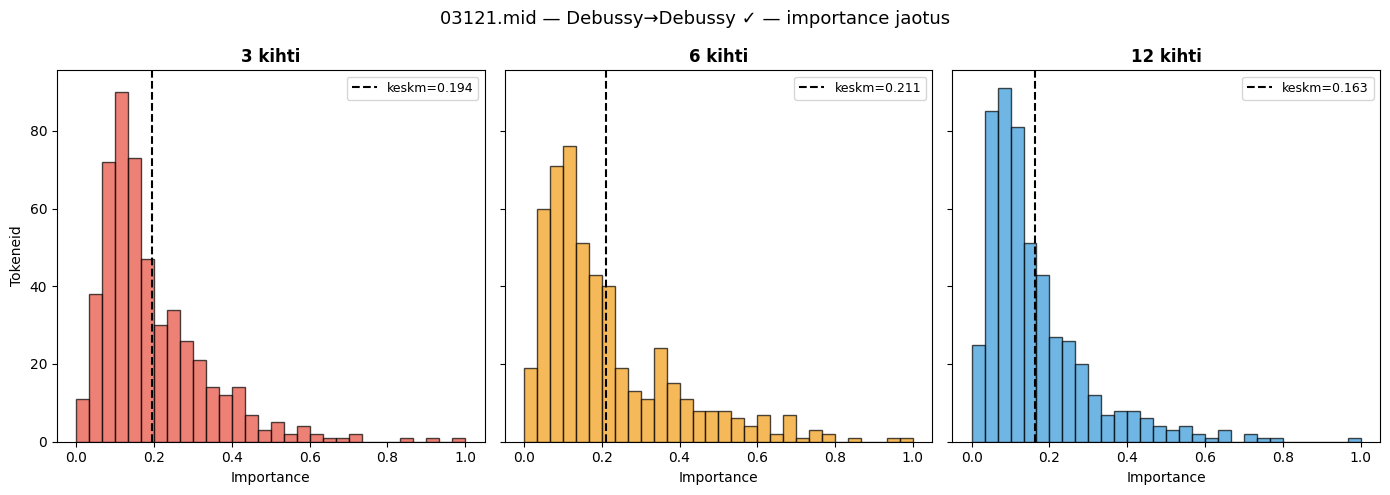

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/03121_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/03121_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/03121_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

ÕIGE: 03048.mid — 99.3% kindlus
Helilooja: Debussy


100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


Ennustus: Debussy (100.0%)
      Bach:   0.0% 
    Mozart:   0.0% 
    Chopin:   0.0% 
   Debussy: 100.0% █████████████████████████████
Tokeneid (mitte-PAD): 512


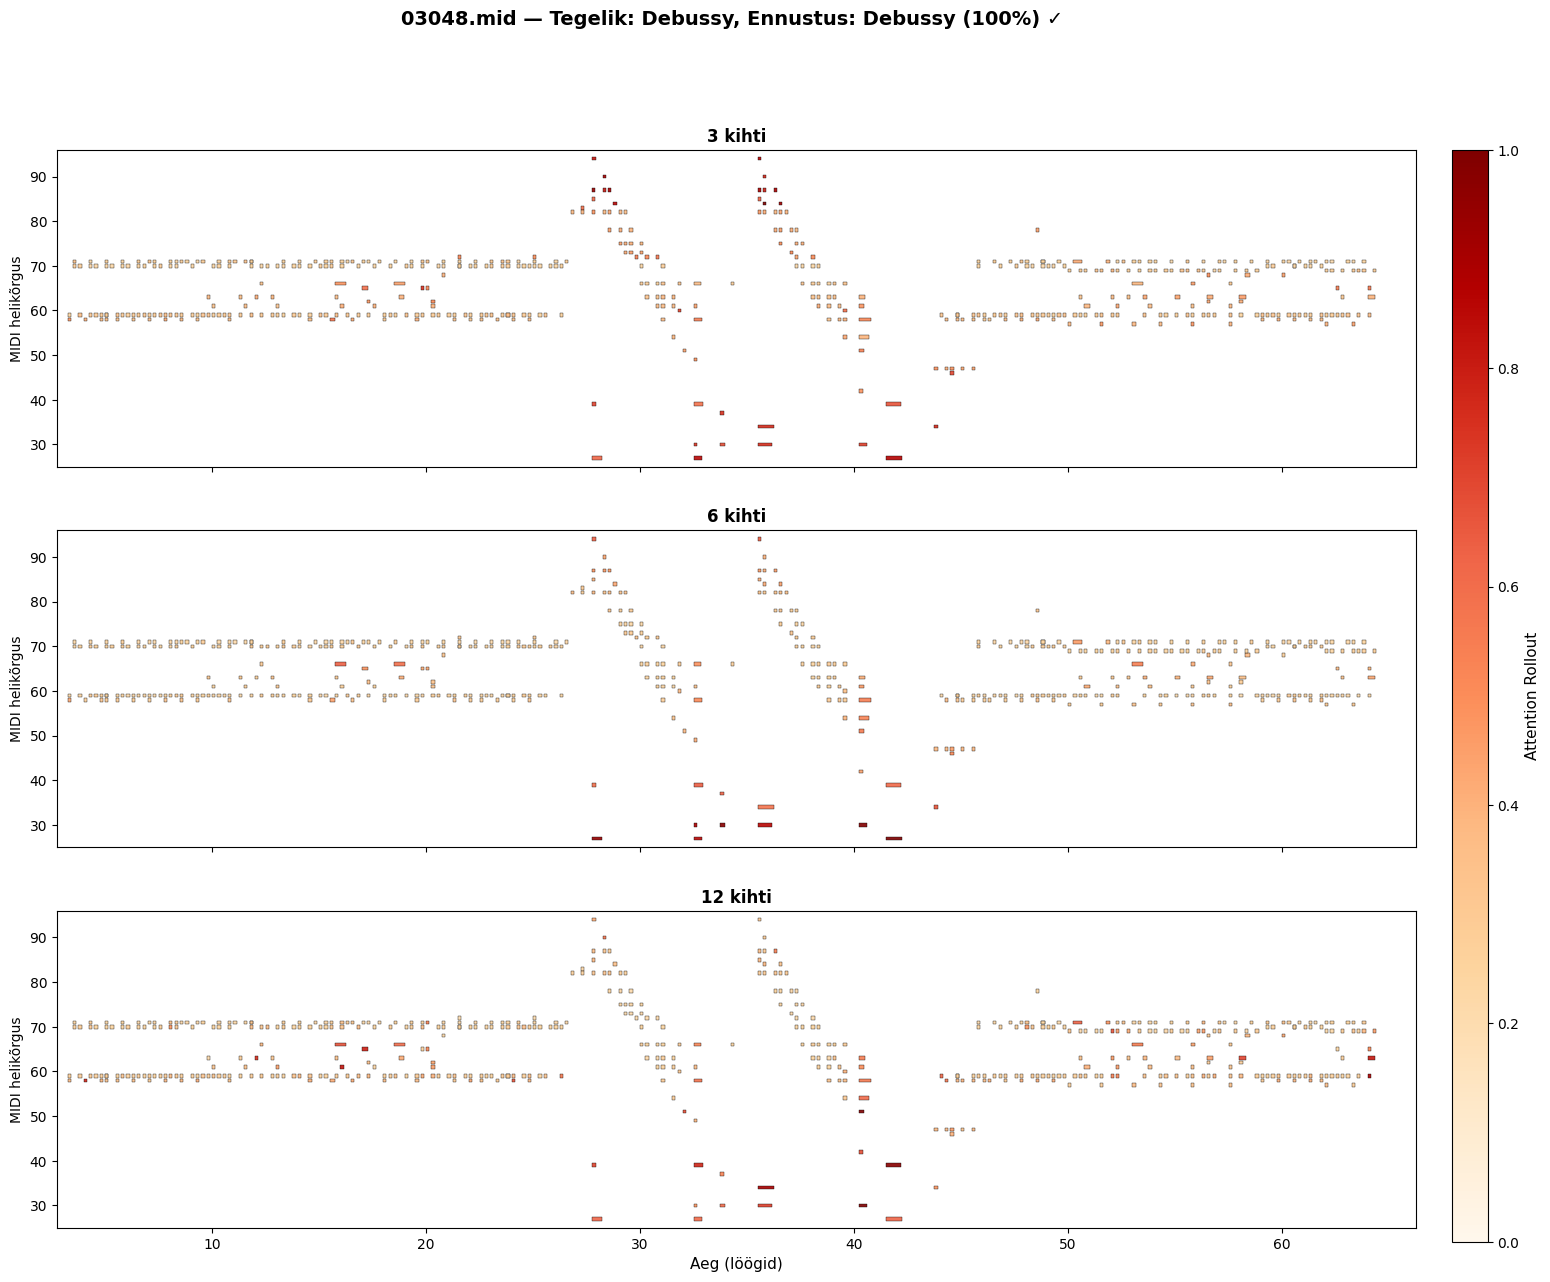

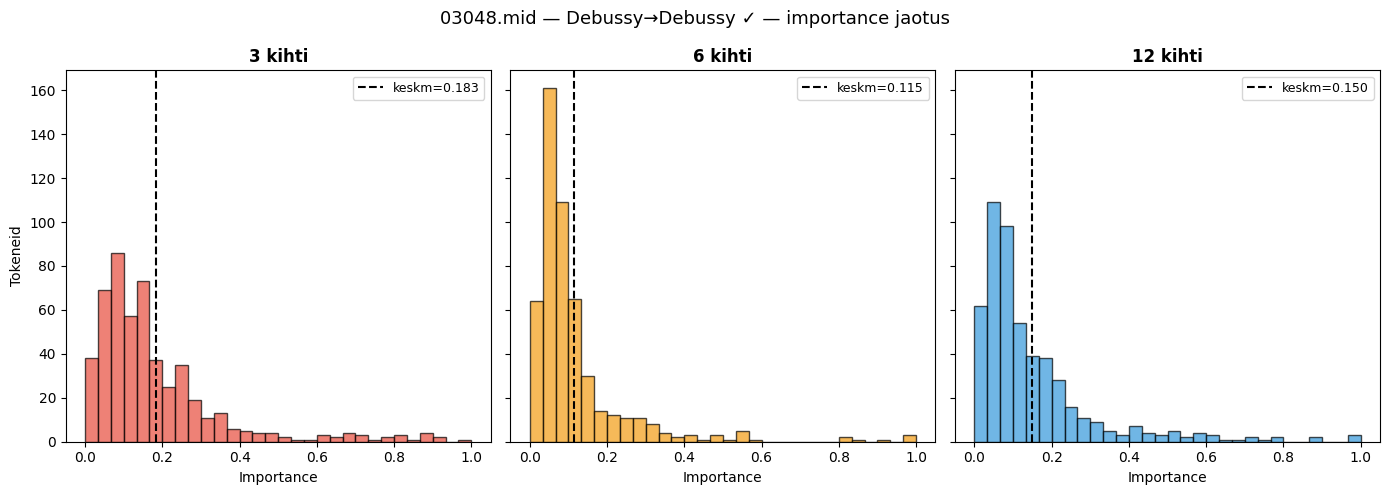

  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/03048_rollout_3kihti.mid
  Velocity vahemik: 5–127 [3 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/03048_rollout_6kihti.mid
  Velocity vahemik: 5–127 [6 kihti]
  MIDI salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp/03048_rollout_12kihti.mid
  Velocity vahemik: 5–127 [12 kihti]

Kontrollgrupp salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/kontrollgrupp

Struktuur:
  /content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout/test/
    huvitav/        — 6 faili (originaal + pildid + 3 rollout MIDI-d)
    kontrollgrupp/  — 8 faili (originaal + pildid + 3 rollout MIDI-d)
VALMIS!


In [ ]:
# # 4. HUVITAVATE PALADE ANALÜÜS

import shutil

# Eksimuspalad (kõige huvitavamad)
misclassified_files = {
    '02672.mid': {'true': 'Bach', 'note': 'Ennustas Chopin 95.9%'},
    '09909.mid': {'true': 'Chopin', 'note': 'Ennustas Mozart 96.1%'},
    '09406.mid': {'true': 'Chopin', 'note': 'Ennustas Debussy 73.8%'},
    '05786.mid': {'true': 'Mozart', 'note': 'Ennustas Bach 63.2%'},
    '03003.mid': {'true': 'Debussy', 'note': 'Ennustas Chopin 64.1%'},
    '09787.mid': {'true': 'Chopin', 'note': 'Ennustas Bach 52.0%'},
}

# Õigesti klassifitseeritud (kontrollgrupiks)
correct_files = {
    '02177.mid': {'true': 'Bach', 'note': '100.0% kindlus'},
    '01911.mid': {'true': 'Bach', 'note': '100.0% kindlus'},
    '05225.mid': {'true': 'Mozart', 'note': '99.8% kindlus'},
    '10775.mid': {'true': 'Mozart', 'note': '99.8% kindlus'},
    '09537.mid': {'true': 'Chopin', 'note': '99.9% kindlus'},
    '11086.mid': {'true': 'Chopin', 'note': '99.9% kindlus'},
    '03121.mid': {'true': 'Debussy', 'note': '99.5% kindlus'},
    '03048.mid': {'true': 'Debussy', 'note': '99.3% kindlus'},
}

# ATEPP kausta tee — otsib failid
atepp_dir = "/content/drive/MyDrive/LÕPUTÖÖ/ATEPP_dataset"
all_atepp_midis = glob.glob(os.path.join(atepp_dir, "**", "*.mid"), recursive=True)
filename_to_path = {os.path.basename(p): p for p in all_atepp_midis}
print(f"ATEPP MIDI faile: {len(filename_to_path)}")

# Väljundkaustad
base_dir = "/content/drive/MyDrive/LÕPUTÖÖ/atepp_rollout"
test_huvitav = os.path.join(base_dir, "test", "huvitav")
test_kontroll = os.path.join(base_dir, "test", "kontrollgrupp")

for d in [test_huvitav, test_kontroll]:
    os.makedirs(d, exist_ok=True)

results = {}

# =============================================================================
# EKSIMUSPALAD (huvitavad)
# =============================================================================
for fname, info in misclassified_files.items():
    if fname not in filename_to_path:
        print(f"\n[VIGA] Faili {fname} ei leitud!")
        continue

    midi_path = filename_to_path[fname]
    true_label = info['true']
    out = test_huvitav

    print(f"\n{'='*60}")
    print(f"EKSIMUS: {fname} — {info['note']}")
    print(f"Tegelik: {true_label}")
    print('='*60)

    result = analyze_midi(midi_path, model, cp_model, device)
    if result is None:
        continue

    result['midi_path'] = midi_path
    results[fname] = {'result': result, 'true_label': true_label}

    # Kopeeri originaal
    shutil.copy2(midi_path, os.path.join(out, fname))

    # 3 kihi variandi võrdlus
    fig = plot_layer_comparison(result, true_label)
    if fig:
        fig.savefig(os.path.join(out, f"{fname[:-4]}_comparison.png"),
                    dpi=150, bbox_inches='tight')
        plt.show()

    # Importance jaotus
    fig2 = plot_importance_distribution(result, true_label)
    if fig2:
        fig2.savefig(os.path.join(out, f"{fname[:-4]}_distribution.png"),
                     dpi=150, bbox_inches='tight')
        plt.show()

    # MIDI väljund (3/6/12 kihti)
    for layer_key, suffix in [('3 kihti', '3'), ('6 kihti', '6'), ('12 kihti', '12')]:
        export_attention_midi(result, os.path.join(out, f"{fname[:-4]}_rollout_{suffix}kihti.mid"),
                              layer_key=layer_key)
        print(f"  Velocity vahemik: 5–127 [{layer_key}]")

print(f"\n\nEksimuspalad salvestatud: {test_huvitav}")

# =============================================================================
# KONTROLLGRUPP: KÕRGE KINDLUSEGA ÕIGED ENNUSTUSED
# =============================================================================
print(f"\n\n{'#'*70}")
print("KONTROLLGRUPP: KÕRGE KINDLUSEGA ÕIGED ENNUSTUSED")
print(f"{'#'*70}")

for fname, info in correct_files.items():
    if fname not in filename_to_path:
        print(f"\n[VIGA] Faili {fname} ei leitud!")
        continue

    midi_path = filename_to_path[fname]
    true_label = info['true']
    out = test_kontroll

    print(f"\n{'='*60}")
    print(f"ÕIGE: {fname} — {info['note']}")
    print(f"Helilooja: {true_label}")
    print('='*60)

    result = analyze_midi(midi_path, model, cp_model, device)
    if result is None:
        continue

    result['midi_path'] = midi_path
    results[fname] = {'result': result, 'true_label': true_label}

    # Kopeerib originaali
    shutil.copy2(midi_path, os.path.join(out, fname))

    # 3 kihi variandi võrdlus
    fig = plot_layer_comparison(result, true_label)
    if fig:
        fig.savefig(os.path.join(out, f"{fname[:-4]}_comparison.png"),
                    dpi=150, bbox_inches='tight')
        plt.show()

    # Importance jaotus
    fig2 = plot_importance_distribution(result, true_label)
    if fig2:
        fig2.savefig(os.path.join(out, f"{fname[:-4]}_distribution.png"),
                     dpi=150, bbox_inches='tight')
        plt.show()

    # MIDI väljund (3/6/12 kihti)
    for layer_key, suffix in [('3 kihti', '3'), ('6 kihti', '6'), ('12 kihti', '12')]:
        export_attention_midi(result, os.path.join(out, f"{fname[:-4]}_rollout_{suffix}kihti.mid"),
                              layer_key=layer_key)
        print(f"  Velocity vahemik: 5–127 [{layer_key}]")

print(f"\nKontrollgrupp salvestatud: {test_kontroll}")

# Kokkuvõte
print(f"\n{'='*50}")
print(f"Struktuur:")
print(f"  {base_dir}/test/")
print(f"    huvitav/        — {len(misclassified_files)} faili (originaal + pildid + 3 rollout MIDI-d)")
print(f"    kontrollgrupp/  — {len(correct_files)} faili (originaal + pildid + 3 rollout MIDI-d)")
print("VALMIS!")

In [ ]:
# =============================================================================
# 4b. KOGU TESTIKOMPLEKTI ANALÜÜS (rollout kõigil testipaladel)
# =============================================================================
# NB: jooksuta PÄRAST sektsiooni 4 (mis analüüsib 14 käsitsi valitud pala).
# Sektsioonid 5 ja 6 kasutavad siit saadud all_results sõnastikku.
# =============================================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm

composer_to_id = {name: i for i, name in enumerate(target_labels)}
# --- Reprodutseerime TÄPSELT sama andmestiku ja spliti kui treeningunotebookis ---

csv_path = os.path.join(atepp_dir, "ATEPP-metadata-1.2.csv")
df = pd.read_csv(csv_path)
df.columns = [col.lower() for col in df.columns]

target_composers_search = ['bach', 'mozart', 'chopin', 'debussy']
filtered_data = []

for _, row in df.iterrows():
    if pd.isna(row['composer']) or pd.isna(row['midi_path']):
        continue
    composer_name = str(row['composer']).lower()
    for target in target_composers_search:
        if target in composer_name:
            csv_filename = os.path.basename(str(row['midi_path']))
            if csv_filename in filename_to_path:
                filtered_data.append({
                    'composer': target.capitalize(),
                    'midi_path': filename_to_path[csv_filename]
                })
            break

filtered_df = pd.DataFrame(filtered_data)
print(f"Filtreeritud palu: {len(filtered_df)}")
print(filtered_df['composer'].value_counts())

# Pala-tasandi andmestik (sama järjekord kui treeningunotebookis)
all_songs = []
song_id_counter = 0
for composer in target_labels:
    composer_files = filtered_df[filtered_df['composer'] == composer]['midi_path'].tolist()
    label_id = composer_to_id[composer]
    for f in composer_files:
        all_songs.append({'path': f, 'label': label_id, 'song_id': song_id_counter})
        song_id_counter += 1

all_labels = np.array([s['label'] for s in all_songs])
all_song_ids = np.array([s['song_id'] for s in all_songs])

# Sama split (random_state=42, test_size=0.1)
_, test_idx = train_test_split(
    np.arange(len(all_songs)), test_size=0.1,
    stratify=all_labels, random_state=42)

print(f"\nTestikomplekti palu: {len(test_idx)}")
for i, name in enumerate(target_labels):
    count = sum(1 for idx in test_idx if all_labels[idx] == i)
    print(f"  {name}: {count}")

# --- Analüüsime KÕIK testipalad ---

all_results = {}
failed = []

for idx in tqdm(test_idx, desc="Rollout kogu testikomplektil"):
    song = all_songs[idx]
    fname = os.path.basename(song['path'])
    true_label = target_labels[song['label']]

    result = analyze_midi(song['path'], model, cp_model, device)
    if result is None:
        failed.append(fname)
        continue
    result['midi_path'] = song['path']
    all_results[fname] = {'result': result, 'true_label': true_label}

print(f"\nEdukalt analüüsitud: {len(all_results)} / {len(test_idx)}")
if failed:
    print(f"Ebaõnnestunud: {len(failed)} faili")

# Kokkuvõte
for name in target_labels:
    n = sum(1 for v in all_results.values() if v['true_label'] == name)
    print(f"  {name}: {n} pala")


Rollout kogu testikomplektil:  43%|████▎     | 180/419 [03:16<04:16,  1.07s/it]

Ennustus: Chopin (71.0%)
      Bach:   3.9% █
    Mozart:  20.4% ██████
    Chopin:  71.0% █████████████████████
   Debussy:   4.7% █
Tokeneid (mitte-PAD): 512



Rollout kogu testikomplektil:  43%|████▎     | 181/419 [03:17<04:10,  1.05s/it]

Ennustus: Mozart (99.5%)
      Bach:   0.3% 
    Mozart:  99.5% █████████████████████████████
    Chopin:   0.0% 
   Debussy:   0.2% 
Tokeneid (mitte-PAD): 512



Rollout kogu testikomplektil:  43%|████▎     | 182/419 [03:18<04:05,  1.04s/it]

...

Ennustus: Bach (100.0%)
      Bach: 100.0% █████████████████████████████
    Mozart:   0.0% 
    Chopin:   0.0% 
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512



Rollout kogu testikomplektil: 100%|█████████▉| 418/419 [07:35<00:00,  1.14it/s]

Ennustus: Mozart (98.2%)
      Bach:   1.6% 
    Mozart:  98.2% █████████████████████████████
    Chopin:   0.2% 
   Debussy:   0.0% 
Tokeneid (mitte-PAD): 512



Rollout kogu testikomplektil: 100%|██████████| 419/419 [07:36<00:00,  1.09s/it]

Ennustus: Mozart (36.9%)
      Bach:  11.1% ███
    Mozart:  36.9% ███████████
    Chopin:  19.1% █████
   Debussy:  32.9% █████████
Tokeneid (mitte-PAD): 512

Edukalt analüüsitud: 419 / 419
  Bach: 132 pala
  Mozart: 72 pala
  Chopin: 183 pala
  Debussy: 32 pala


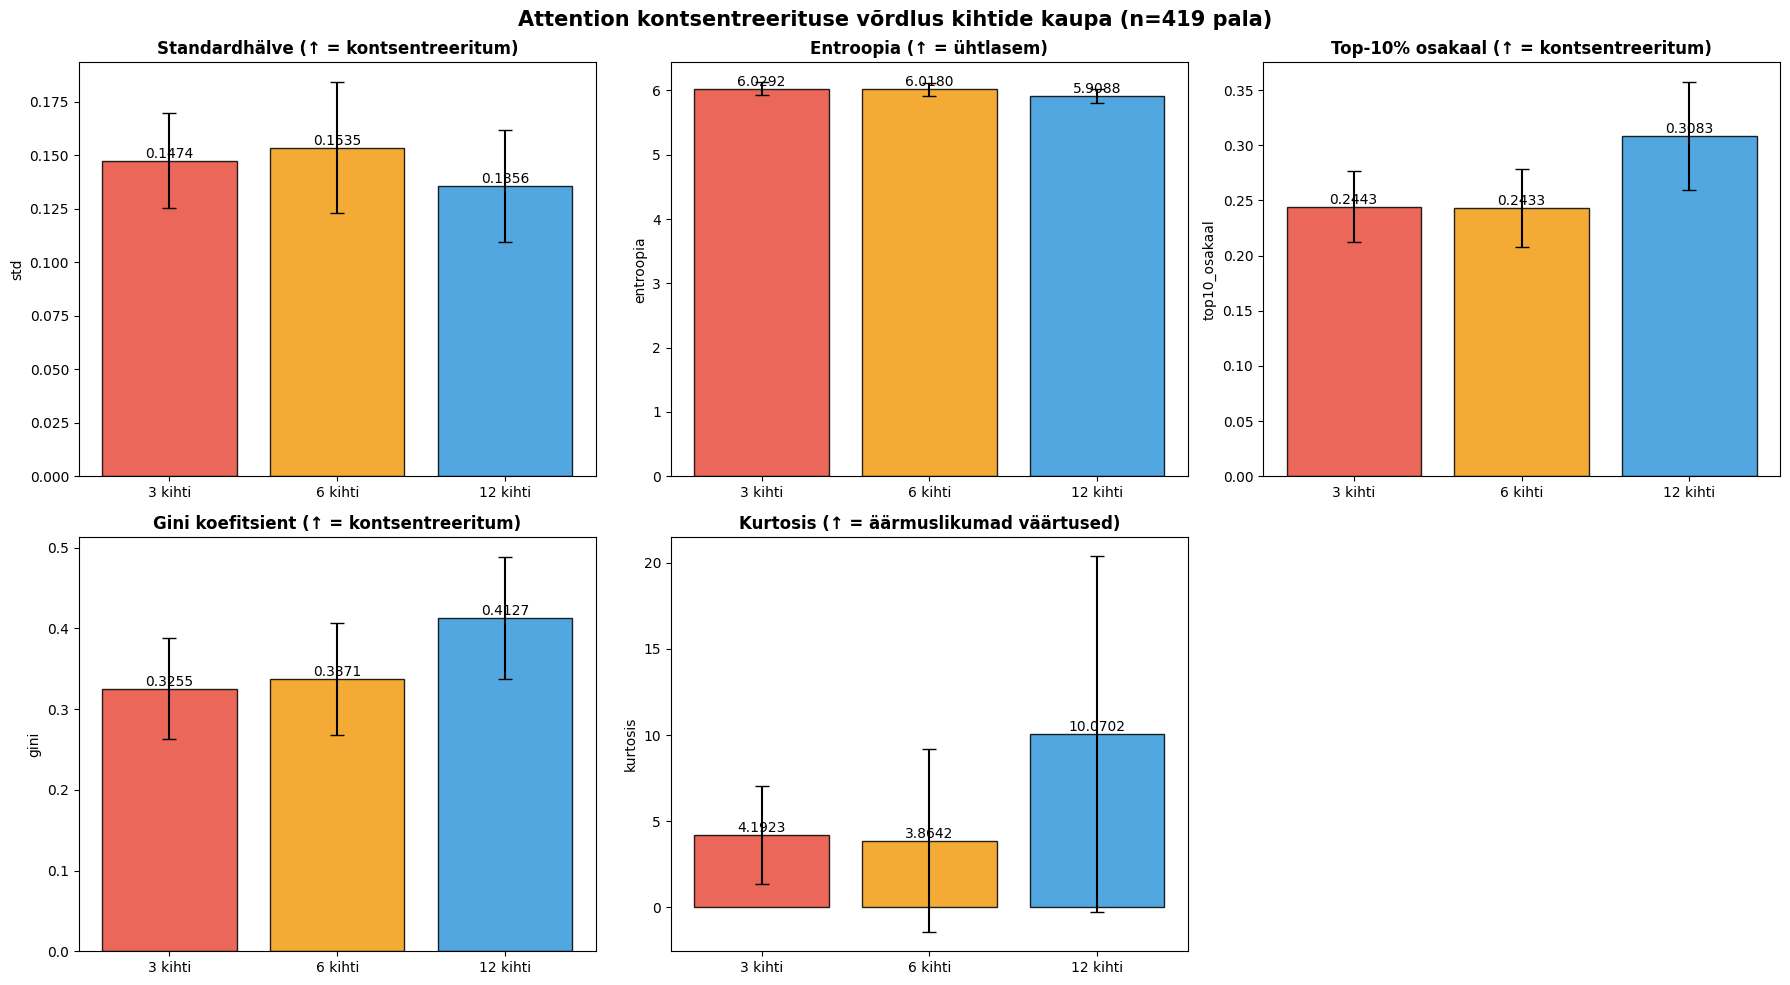


Kontsentreerituse mõõdikud (keskmine üle 419 testipala):
               std  entroopia  top10_osakaal      gini   kurtosis
kihid                                                            
3 kihti   0.147369   6.029240       0.244309  0.325468   4.192299
6 kihti   0.153527   6.017955       0.243300  0.337137   3.864188
12 kihti  0.135592   5.908751       0.308349  0.412719  10.070162


Tõlgendus:
----------------------------------------------------------------------
  std: 3 kihti=0.1474, 12 kihti=0.1356 → 3 kihti on kontsentreeritum
  entroopia: 3 kihti=6.0292, 12 kihti=5.9088 → 12 kihti on kontsentreeritum
  top10_osakaal: 3 kihti=0.2443, 12 kihti=0.3083 → 3 kihti on ühtlasem
  gini: 3 kihti=0.3255, 12 kihti=0.4127 → 3 kihti on ühtlasem
  kurtosis: 3 kihti=4.1923, 12 kihti=10.0702 → 12 kihti on äärmuslikumad sabad


LISA: Kontsentreerituse erinevus õigete vs valede ennustuste vahel

  3 kihti:
    Õiged (n=360):  std=0.1482, gini=0.3284, top10=0.2457
    Valed (n=59):  std=0.1420, g

In [ ]:
# # 5. KAS 12 KIHTI = ÜHTLASEM, 3 KIHTI = KONTSENTREERITUM?

from scipy.stats import entropy, kurtosis

concentration_rows = []
for fname, data in all_results.items():
    result = data['result']
    true_label = data['true_label']
    token_notes = result['token_notes']
    pred_label = target_labels[result['predicted_class']]

    for layer_key in ['3 kihti', '6 kihti', '12 kihti']:
        importances = np.array([tn['importance'][layer_key] for tn in token_notes])

        std = np.std(importances)

        imp_norm = importances / importances.sum() if importances.sum() > 0 else importances
        ent = entropy(imp_norm + 1e-10)

        threshold = np.percentile(importances, 90)
        top10_mass = importances[importances >= threshold].sum() / (importances.sum() + 1e-10)

        sorted_imp = np.sort(importances)
        n = len(sorted_imp)
        index = np.arange(1, n + 1)
        gini = (2 * np.sum(index * sorted_imp) / (n * np.sum(sorted_imp) + 1e-10)) - (n + 1) / n

        kurt = kurtosis(importances, fisher=True)

        concentration_rows.append({
            'fail': fname,
            'helilooja': true_label,
            'ennustus': pred_label,
            'oige': pred_label == true_label,
            'kihid': layer_key,
            'std': std,
            'entroopia': ent,
            'top10_osakaal': top10_mass,
            'gini': gini,
            'kurtosis': kurt
        })

cdf = pd.DataFrame(concentration_rows)

# --- Joonis: mõõdikute võrdlus kihtide kaupa ---
metrics = [('std', 'Standardhälve (↑ = kontsentreeritum)'),
           ('entroopia', 'Entroopia (↑ = ühtlasem)'),
           ('top10_osakaal', 'Top-10% osakaal (↑ = kontsentreeritum)'),
           ('gini', 'Gini koefitsient (↑ = kontsentreeritum)'),
           ('kurtosis', 'Kurtosis (↑ = äärmuslikumad väärtused)')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flat
layer_order = ['3 kihti', '6 kihti', '12 kihti']
colors = ['#e74c3c', '#f39c12', '#3498db']

for ax, (col, title) in zip(axes_flat, metrics):
    means = cdf.groupby('kihid')[col].mean().reindex(layer_order)
    stds = cdf.groupby('kihid')[col].std().reindex(layer_order)
    bars = ax.bar(layer_order, means, yerr=stds, color=colors, edgecolor='black',
                  capsize=5, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(col)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

axes_flat[5].set_visible(False)

n_palu = len(all_results)
fig.suptitle(f'Attention kontsentreerituse võrdlus kihtide kaupa (n={n_palu} pala)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(base_dir, "test", "kontsentreerituse_vordlus.png"),
            dpi=150, bbox_inches='tight')
plt.show()

# --- Numbriline kokkuvõte ---
print(f"\nKontsentreerituse mõõdikud (keskmine üle {n_palu} testipala):")
print("=" * 70)
summary = cdf.groupby('kihid')[['std', 'entroopia', 'top10_osakaal', 'gini', 'kurtosis']].mean().reindex(layer_order)
print(summary.to_string())

print("\n\nTõlgendus:")
print("-" * 70)
for col, title in metrics:
    vals = summary[col]
    if col == 'entroopia':
        trend = "ühtlasem" if vals.iloc[-1] > vals.iloc[0] else "kontsentreeritum"
        print(f"  {col}: 3 kihti={vals.iloc[0]:.4f}, 12 kihti={vals.iloc[2]:.4f} → 12 kihti on {trend}")
    elif col == 'kurtosis':
        trend = "äärmuslikumad sabad" if vals.iloc[-1] > vals.iloc[0] else "ühtlasemad sabad"
        print(f"  {col}: 3 kihti={vals.iloc[0]:.4f}, 12 kihti={vals.iloc[2]:.4f} → 12 kihti on {trend}")
    else:
        trend = "kontsentreeritum" if vals.iloc[0] > vals.iloc[-1] else "ühtlasem"
        print(f"  {col}: 3 kihti={vals.iloc[0]:.4f}, 12 kihti={vals.iloc[2]:.4f} → 3 kihti on {trend}")

# --- LISA: kas õigete ja valede ennustuste kontsentreerituses on vahe? ---
print(f"\n\n{'='*70}")
print("LISA: Kontsentreerituse erinevus õigete vs valede ennustuste vahel")
print(f"{'='*70}")

for layer_key in layer_order:
    sub = cdf[cdf['kihid'] == layer_key]
    oige = sub[sub['oige'] == True]
    vale = sub[sub['oige'] == False]
    print(f"\n  {layer_key}:")
    print(f"    Õiged (n={len(oige)}):  std={oige['std'].mean():.4f}, "
          f"gini={oige['gini'].mean():.4f}, top10={oige['top10_osakaal'].mean():.4f}")
    if len(vale) > 0:
        print(f"    Valed (n={len(vale)}):  std={vale['std'].mean():.4f}, "
              f"gini={vale['gini'].mean():.4f}, top10={vale['top10_osakaal'].mean():.4f}")
    else:
        print(f"    Valed: 0 pala")

Bachi/Mozarti pitch vahemik (kogu testikomplekt): 25–93
  (MIDI 25 = C#1, MIDI 93 = A6)

Chopini palu testikomplektis: 183
Debussy palu testikomplektis: 32

Keskmine importance: B/M ulatuse sees vs väljas

  Chopin:
    3 kihti: sees=0.2480 (n=89563), väljas=0.6625 (n=365), vahe=+0.4145 ↑ KÕRGEM
    6 kihti: sees=0.2516 (n=89563), väljas=0.5293 (n=365), vahe=+0.2777 ↑ KÕRGEM
    12 kihti: sees=0.1727 (n=89563), väljas=0.1538 (n=365), vahe=-0.0189 ↓ MADALAM

  Debussy:
    3 kihti: sees=0.2232 (n=16322), väljas=0.7730 (n=62), vahe=+0.5499 ↑ KÕRGEM
    6 kihti: sees=0.1899 (n=16322), väljas=0.5045 (n=62), vahe=+0.3146 ↑ KÕRGEM
    12 kihti: sees=0.1495 (n=16322), väljas=0.1251 (n=62), vahe=-0.0244 ↓ MADALAM


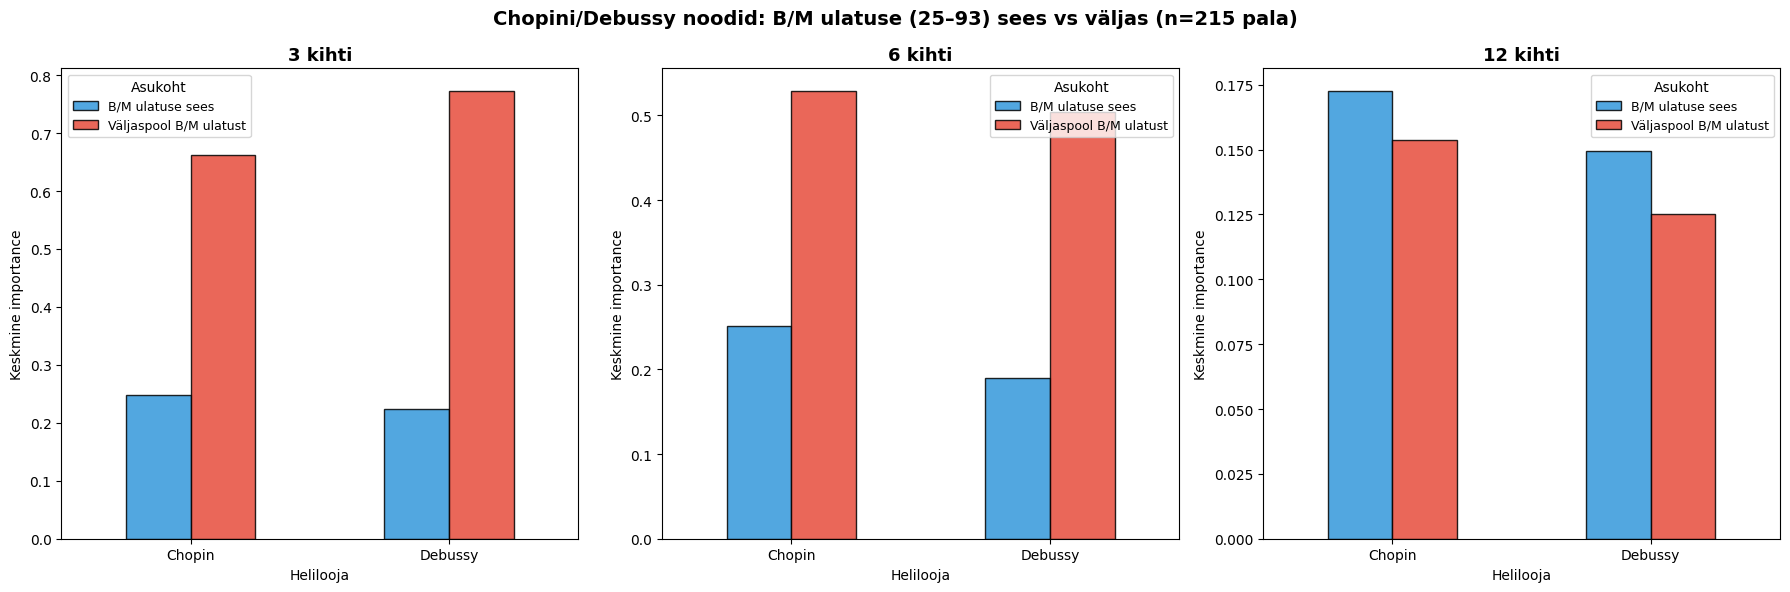

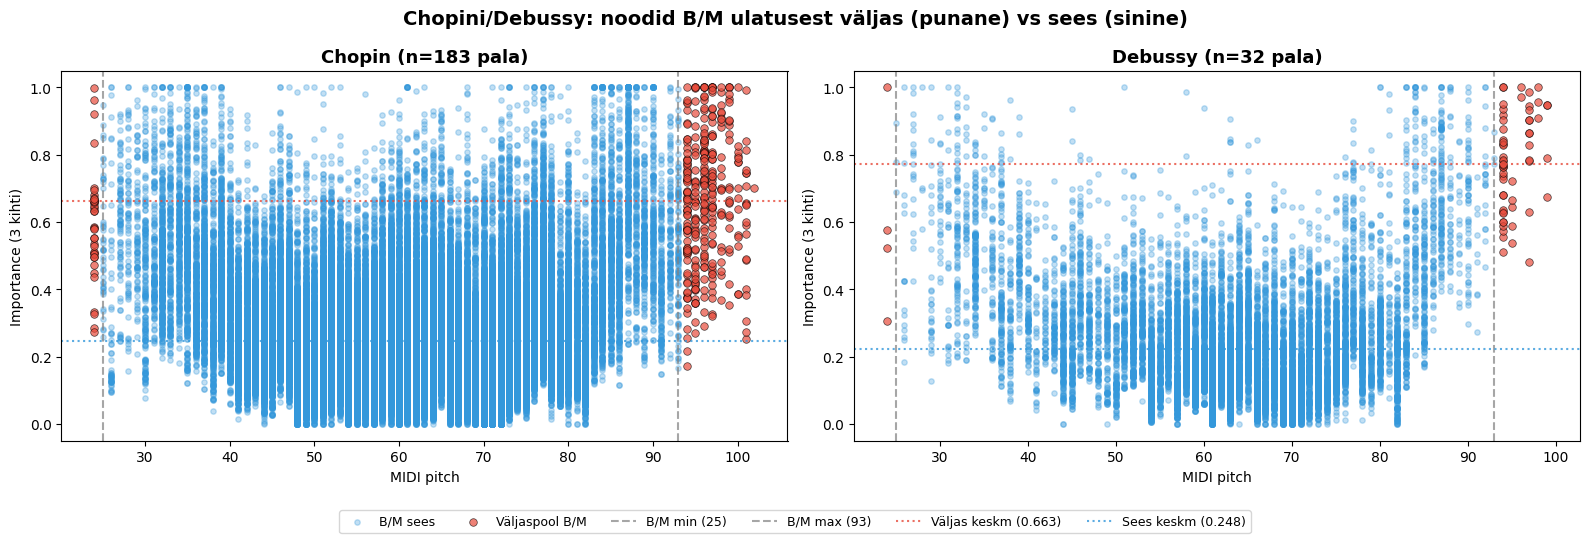



Mann-Whitney U test (n=215 pala):
  Chopin [3 kihti]: U=30803311, p=0.000000 ***, r=-0.885, n_sees=89563, n_väljas=365
  Chopin [6 kihti]: U=27639806, p=0.000000 ***, r=-0.691, n_sees=89563, n_väljas=365
  Chopin [12 kihti]: U=16362693, p=0.485942 ns, r=-0.001, n_sees=89563, n_väljas=365
  Debussy [3 kihti]: U=989820, p=0.000000 ***, r=-0.956, n_sees=16322, n_väljas=62
  Debussy [6 kihti]: U=944556, p=0.000000 ***, r=-0.867, n_sees=16322, n_väljas=62
  Debussy [12 kihti]: U=524935, p=0.305075 ns, r=-0.037, n_sees=16322, n_väljas=62


Kokkuvõte efekti suurustest:
----------------------------------------------------------------------
  |r| < 0.1 = tühine, 0.1–0.3 = väike, 0.3–0.5 = keskmine, > 0.5 = suur


In [ ]:
# # 6. KAS BACHI/MOZARTI ULATUSEST VÄLJAS OLEVAD NOODID ON OLULISEMAD?

from scipy.stats import mannwhitneyu

# Leia Bachi ja Mozarti pitch vahemik kogu testikomplektist
bach_mozart_pitches = []
for fname, data in all_results.items():
    if data['true_label'] in ['Bach', 'Mozart']:
        for tn in data['result']['token_notes']:
            bach_mozart_pitches.append(tn['pitch'])

bm_min = min(bach_mozart_pitches)
bm_max = max(bach_mozart_pitches)
print(f"Bachi/Mozarti pitch vahemik (kogu testikomplekt): {bm_min}–{bm_max}")
note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
print(f"  (MIDI {bm_min} = {note_names[bm_min%12]}{bm_min//12-1}, "
      f"MIDI {bm_max} = {note_names[bm_max%12]}{bm_max//12-1})")
print()

# Analüüsi Chopini ja Debussy noote: sees vs väljas
rows = []
for fname, data in all_results.items():
    if data['true_label'] not in ['Chopin', 'Debussy']:
        continue
    for tn in data['result']['token_notes']:
        for layer_key in ['3 kihti', '6 kihti', '12 kihti']:
            on_väljas = tn['pitch'] < bm_min or tn['pitch'] > bm_max
            rows.append({
                'fail': fname,
                'helilooja': data['true_label'],
                'pitch': tn['pitch'],
                'importance': tn['importance'][layer_key],
                'kihid': layer_key,
                'asukoht': 'Väljaspool B/M ulatust' if on_väljas else 'B/M ulatuse sees'
            })

df_ext = pd.DataFrame(rows)

# --- Numbriline kokkuvõte ---
n_chopin = sum(1 for v in all_results.values() if v['true_label'] == 'Chopin')
n_debussy = sum(1 for v in all_results.values() if v['true_label'] == 'Debussy')

print(f"Chopini palu testikomplektis: {n_chopin}")
print(f"Debussy palu testikomplektis: {n_debussy}")
print(f"\nKeskmine importance: B/M ulatuse sees vs väljas")
print("=" * 70)
for composer in ['Chopin', 'Debussy']:
    print(f"\n  {composer}:")
    sub = df_ext[df_ext['helilooja'] == composer]
    for lk in ['3 kihti', '6 kihti', '12 kihti']:
        lk_sub = sub[sub['kihid'] == lk]
        sees = lk_sub[lk_sub['asukoht'] == 'B/M ulatuse sees']['importance']
        väljas = lk_sub[lk_sub['asukoht'] == 'Väljaspool B/M ulatust']['importance']
        n_väljas = len(väljas)
        n_sees = len(sees)
        if n_väljas > 0:
            diff = väljas.mean() - sees.mean()
            suund = "↑ KÕRGEM" if diff > 0 else "↓ MADALAM"
            print(f"    {lk}: sees={sees.mean():.4f} (n={n_sees}), "
                  f"väljas={väljas.mean():.4f} (n={n_väljas}), "
                  f"vahe={diff:+.4f} {suund}")
        else:
            print(f"    {lk}: kõik noodid B/M ulatuse sees (n={n_sees})")

# --- Joonis: sees vs väljas võrdlus ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
layer_keys = ['3 kihti', '6 kihti', '12 kihti']
bar_colors = {'B/M ulatuse sees': '#3498db', 'Väljaspool B/M ulatust': '#e74c3c'}

for ax, lk in zip(axes, layer_keys):
    sub = df_ext[df_ext['kihid'] == lk]
    pivot = sub.groupby(['helilooja', 'asukoht'])['importance'].mean().unstack(fill_value=0)
    pivot.plot(kind='bar', ax=ax,
               color=[bar_colors.get(c, '#999') for c in pivot.columns],
               edgecolor='black', alpha=0.85)
    ax.set_title(f'{lk}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Helilooja')
    ax.set_ylabel('Keskmine importance')
    ax.legend(title='Asukoht', fontsize=9)
    ax.tick_params(axis='x', rotation=0)

fig.suptitle(f'Chopini/Debussy noodid: B/M ulatuse ({bm_min}–{bm_max}) sees vs väljas '
             f'(n={n_chopin + n_debussy} pala)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(base_dir, "test", "ulatus_sees_vs_valjas.png"),
            dpi=150, bbox_inches='tight')
plt.show()

# --- Joonis 2: scatter pitch vs importance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, composer in zip(axes, ['Chopin', 'Debussy']):
    sub = df_ext[(df_ext['helilooja'] == composer) & (df_ext['kihid'] == '3 kihti')]
    sees = sub[sub['asukoht'] == 'B/M ulatuse sees']
    väljas = sub[sub['asukoht'] == 'Väljaspool B/M ulatust']

    ax.scatter(sees['pitch'], sees['importance'], alpha=0.3, s=15,
               c='#3498db', label='B/M sees')
    ax.scatter(väljas['pitch'], väljas['importance'], alpha=0.7, s=30,
               c='#e74c3c', edgecolors='black', linewidth=0.5,
               label='Väljaspool B/M')
    ax.axvline(bm_min, color='grey', linestyle='--', alpha=0.7,
               label=f'B/M min ({bm_min})')
    ax.axvline(bm_max, color='grey', linestyle='--', alpha=0.7,
               label=f'B/M max ({bm_max})')

    if len(väljas) > 0:
        ax.axhline(väljas['importance'].mean(), color='#e74c3c',
                   linestyle=':', alpha=0.8,
                   label=f'Väljas keskm ({väljas["importance"].mean():.3f})')
    ax.axhline(sees['importance'].mean(), color='#3498db',
               linestyle=':', alpha=0.8,
               label=f'Sees keskm ({sees["importance"].mean():.3f})')

    n_palu_composer = sum(1 for v in all_results.values()
                          if v['true_label'] == composer)
    ax.set_title(f'{composer} (n={n_palu_composer} pala)', fontsize=13,
                 fontweight='bold')
    ax.set_xlabel('MIDI pitch')
    ax.set_ylabel('Importance (3 kihti)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Chopini/Debussy: noodid B/M ulatusest väljas (punane) vs sees (sinine)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(base_dir, "test", "ulatus_scatter_sees_vs_valjas.png"),
            dpi=150, bbox_inches='tight')
plt.show()

# --- Statistiline test (nüüd suurema valimiga) ---
print(f"\n\nMann-Whitney U test (n={n_chopin + n_debussy} pala):")
print("=" * 70)
for composer in ['Chopin', 'Debussy']:
    for lk in ['3 kihti', '6 kihti', '12 kihti']:
        sub = df_ext[(df_ext['helilooja'] == composer) & (df_ext['kihid'] == lk)]
        sees = sub[sub['asukoht'] == 'B/M ulatuse sees']['importance']
        väljas = sub[sub['asukoht'] == 'Väljaspool B/M ulatust']['importance']
        if len(väljas) >= 5:
            stat, p = mannwhitneyu(väljas, sees, alternative='greater')
            tähis = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            # Efekti suurus (rank-biserial korrelatsioon)
            r = 1 - (2 * stat) / (len(sees) * len(väljas))
            print(f"  {composer} [{lk}]: U={stat:.0f}, p={p:.6f} {tähis}, "
                  f"r={r:.3f}, n_sees={len(sees)}, n_väljas={len(väljas)}")
        else:
            print(f"  {composer} [{lk}]: liiga vähe noote väljaspool (n={len(väljas)})")

# --- LISA: efekti suurus heliloojate kaupa ---
print(f"\n\nKokkuvõte efekti suurustest:")
print("-" * 70)
print("  |r| < 0.1 = tühine, 0.1–0.3 = väike, 0.3–0.5 = keskmine, > 0.5 = suur")


In [ ]:
# =============================================================================
# 6b. PALA-TASANDI ANALÜÜS (paaris-test — Wilcoxoni astakmärkide test)
# =============================================================================
# Iga pala kohta arvutatakse keskmine importance sees ja väljas.
# Võrreldakse AINULT palasid, kus on mõlemad grupid esindatud.
# Kasutatakse Wilcoxoni astakmärkide testi (sõltuvad paarid).

from scipy.stats import wilcoxon

print(f"\n\n{'='*70}")
print("PALA-TASANDI ANALÜÜS (Wilcoxoni astakmärkide test, paaris-palad)")
print(f"{'='*70}")

for composer in ['Chopin', 'Debussy']:
    print(f"\n  {composer}:")
    for lk in ['3 kihti', '6 kihti', '12 kihti']:
        sub = df_ext[(df_ext['helilooja'] == composer) & (df_ext['kihid'] == lk)]

        # Iga pala kohta: keskmine importance sees JA väljas (ainult paarid)
        pala_sees = []
        pala_väljas = []
        n_total = 0

        for fname, pala_df in sub.groupby('fail'):
            n_total += 1
            sees = pala_df[pala_df['asukoht'] == 'B/M ulatuse sees']['importance']
            väljas = pala_df[pala_df['asukoht'] == 'Väljaspool B/M ulatust']['importance']

            # Ainult palad, kus ON mõlemad grupid
            if len(sees) > 0 and len(väljas) > 0:
                pala_sees.append(sees.mean())
                pala_väljas.append(väljas.mean())

        n_pairs = len(pala_sees)

        if n_pairs < 5:
            print(f"    {lk}: liiga vähe paaris-palasid (n={n_pairs})")
            continue

        pala_sees_arr = np.array(pala_sees)
        pala_väljas_arr = np.array(pala_väljas)
        differences = pala_väljas_arr - pala_sees_arr

        stat, p = wilcoxon(differences, alternative='greater')

        # Matched-pairs rank-biserial korrelatsioon
        n = len(differences)
        r = 1 - (2 * stat) / (n * (n + 1) / 2)

        tähis = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "eo"

        print(f"    {lk}: sees={pala_sees_arr.mean():.4f}, "
              f"väljas={pala_väljas_arr.mean():.4f}, "
              f"vahe={differences.mean():+.4f}")
        print(f"          n={n_pairs} paaris-pala (kokku {n_total} pala), "
              f"W={stat:.0f}, p={p:.6f} {tähis}, r={r:.3f}")



PALA-TASANDI ANALÜÜS (Wilcoxoni astakmärkide test, paaris-palad)

  Chopin:
    3 kihti: sees=0.2530, väljas=0.6775, vahe=+0.4245
          n=58 paaris-pala (kokku 183 pala), W=1711, p=0.000000 ***, r=-1.000
    6 kihti: sees=0.2327, väljas=0.5727, vahe=+0.3400
          n=58 paaris-pala (kokku 183 pala), W=1711, p=0.000000 ***, r=-1.000
    12 kihti: sees=0.1641, väljas=0.1629, vahe=-0.0013
          n=58 paaris-pala (kokku 183 pala), W=793, p=0.685770 eo, r=0.073

  Debussy:
    3 kihti: sees=0.2245, väljas=0.8199, vahe=+0.5954
          n=21 paaris-pala (kokku 32 pala), W=231, p=0.000000 ***, r=-1.000
    6 kihti: sees=0.1827, väljas=0.5397, vahe=+0.3570
          n=21 paaris-pala (kokku 32 pala), W=231, p=0.000000 ***, r=-1.000
    12 kihti: sees=0.1511, väljas=0.1340, vahe=-0.0170
          n=21 paaris-pala (kokku 32 pala), W=61, p=0.972653 eo, r=0.472
